# `**ШЕРИНГОВЫЕ УСЛУГИ. Анализ спроса на самокаты.**`

## К нам "обратилась" компания, предоставляющая самокаты в аренду. Она не так давно вышла на рынок, успела накопить некоторые данные по поездкам и теперь желает оптимизировать свой бизнес - перейти на динамический тип ценообразования.

# Задача:проанализировать эффективность текущей деятельности компании,выявить факторы, влияющие на спрос.

# План:
# 0.Предобработка данных
# 1. Проведение расчетов и исследований.
#    1.1 Итоговая стоимость
#    1.2 Таблица почасовый трафик
 #   1.3 Корреляция между параметрами погоды
# 2.Проверка гипотез
# -наши гипотезы
# 3.Регрессивное моделирование
#    3.1 Факторы
#    3.2 Нюансы
# 4.Дашборд и презентация    
# 5. Сдача проекта

#**0.Предобработка. Знакомство с данными**

Два файла: weather.csv и rides.csv

# Weather.csv

In [37]:
import pandas as pd


w = pd.read_csv('weather.csv')
w.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3673 entries, 0 to 3672
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Datetime             3672 non-null   object
 1   Temperature          3618 non-null   object
 2   Precipitation Total  3643 non-null   object
 3   Wind Gust            3673 non-null   object
 4   Wind Speed           3657 non-null   object
 5   Cloud Cover Total    3653 non-null   object
 6   Sunshine Duration    3661 non-null   object
dtypes: object(7)
memory usage: 201.0+ KB


 Пояснение:
 0   Datetime -  время измерения             
 1   Temperature - температура воздуха          
 2   Precipitation Total - осадки  
 3   Wind Gust - скорость ветра            
 4   Wind Speed - порывы ветра (макс скорость)           
 5   Cloud Cover Total - облачность (% покрытия)    
 6   Sunshine Duration - Солнечное сияние (мин)

# Rides.csv

In [2]:
import pandas as pd


df = pd.read_csv('rides.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Id              102255 non-null  int64  
 1   Start Date      102255 non-null  object 
 2   End Date        102255 non-null  object 
 3   Start Location  102255 non-null  object 
 4   Start District  102255 non-null  object 
 5   End Location    102255 non-null  object 
 6   End District    102255 non-null  object 
 7   Distance        101022 non-null  float64
 8   Promo           102255 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.0+ MB


 0   Id - идентификатор поездки              
 1   Start Date - Start Datetime     
 2   End Date - End Datetime        
 3   Start Location - Start Location  
 4   Start District - Start District   
 5   End Location - End Location    
 6   End District - End District    
 7   Distance - Distance        
 8   Promo - применен ли промо-код на бесплатный старт    

# *Предобработаем данные по следующему плану:**

## 1. Наименования столбцов - pep-8
## 2. Тип данных
## 3. Явные дубликаты (До стат. расчетов, чтобы не было смещения!)
## 4. Неявные дубликаты (Категориальные столбцы)
## 5. Аномалии/выбросы
  ## 5.1. Предположить причину возникновения, подумать о необходимости обработки
  ## 5.2. Если обработка нужна, то подход как к пропускам (в следующем пункте)
## 6. Пропуски
  ## 6.1. Стратегий несколько, вопрос в том, как обоснуете свое решение
  ## 6.2. Можно учесть взаимосвязи в данных: погода – соседние по времени наблюдения, поездки
## – время/расстояние/скорость, расстояние между районами
## 7. Аналитический и графический анализ данных + выводы (Сколько и чего имеем по результатам
## обработки)

# **1.Проведение расчетов и исследований.**

- файл 1_week_clean.ipynb

In [3]:
import os
import ast
import pandas as pd
import numpy as np
import seaborn as sns
import re


import matplotlib.pyplot as plt
# PATH_OUT = r'D:\code_files\Python\data_analysis_yandex\yandex_final\git\SADTeam\Настя'

Общая информация про файл rides.csv

In [4]:
df = pd.read_csv('rides.csv', sep=',', encoding='utf-8', skipinitialspace=True, decimal=',')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102255 entries, 0 to 102254
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Id              102255 non-null  int64 
 1   Start Date      102255 non-null  object
 2   End Date        102255 non-null  object
 3   Start Location  102255 non-null  object
 4   Start District  102255 non-null  object
 5   End Location    102255 non-null  object
 6   End District    102255 non-null  object
 7   Distance        101022 non-null  object
 8   Promo           102255 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 7.0+ MB


### Столбец	Тип признака Описание
#### *Id* - Уникальный идентификатор. Идентификатор поездки, номинативный, может рассматриваться как индекс.
#### *Start Date* - Временной (datetime). Дата и время начала поездки.
#### *End Date* - Временной (datetime). Дата и время окончания поездки.
#### *Start Location* - Категориальный. Название улицы старта.
#### *Start District* - Категориальный. Район отправления.
#### *End Location* - Категориальный. Название улицы прибытия.
#### *End District* - Категориальный. Район прибытия.
#### *Distance* - Количественный (непрерывный). Пройденное расстояние, в метрах.
#### *Promo* - Категориальный (бинарный). Флаг: была ли акция (0/1).

# Очистка DataFrame df, удаляем некорректные строки и преобразуя даты.

## Явные дубликаты

In [5]:
initial_count = len(df)
df = df.drop_duplicates()
final_count = len(df)

removed = initial_count - final_count
print(f"Удалено дубликатов: {removed}")

Удалено дубликатов: 4883


** БУдалено дубликатов: 4883**
** Было: 102255, Стало: 97372**

In [6]:
df.reset_index(drop=True)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,Шевченко,Юго-Восточный,Майская,Октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,Чехова,заречный,Спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,Буденного,Октябрьский,Суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,Труда,Центральный,Рабочая,Северо-Западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,Первомайская,Северо-Западный,Юбилейная,Юго-Восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,Лесная,Юго-Восточный,Западная,Ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,Пролетарская,Центральный,Свободы,Ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,Комарова,Ленинский,ул. западная,Ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,Западная,ленинский,Озерная,Юго-Восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,Свободы,ленинский,ул. чкалова,юго-восточный,5263.0,0


## Неявные дубликаты

In [7]:
print(df['Start Location'].unique(), df['Start District'].unique())

['Шевченко' 'Чехова' 'Буденного' 'Труда' 'Первомайская' 'Лесная'
 'Пролетарская' 'Комарова' 'Западная' 'Свободы' 'Коммунальная' 'Зеленая'
 'Шоссейная' 'Центральная' 'буденного' 'новая' 'Энтузиастов'
 'ул.подгорная' 'Восточная' 'Лермонтова' 'Школьная' 'Пушкина' 'подгорная'
 'рябиновая' 'Солнечная' 'Мичурина' 'ул труда' 'Партизанская' 'Вокзальная'
 'Комсомольская' 'майская' 'Красноармейская' 'Рабочая' 'Почтовая' 'дачная'
 'Заводская' 'Ломоносова' 'карла маркса' 'Советская' 'Красная'
 'Дзержинского' 'Рябиновая' 'ул.советская' 'ул.энергетиков' 'Пионерская'
 'ленина' 'ул. сиреневая' 'гагарина' 'юбилейная' 'Цветочная'
 'ул. набережная' 'Сосновая' 'Спортивная' 'Новая' 'Ленина' 'Полевая'
 'ул. строительная' 'Майская' 'Озерная' 'ул.горького' 'ул. восточная'
 'пионерская' 'Энергетиков' 'ул.озерная' 'южная' 'Некрасова'
 'ул.молодежная' 'ул. пионерская' 'Чкалова' 'Речная' 'Парковая'
 'Карла Маркса' 'строителей' 'Кирова' 'Набережная' 'матросова' 'Садовая'
 'колхозная' 'ул. чкалова' 'комарова' 'Луго

**Замена названий улиц**

In [8]:
df['Start District'] = df['Start District'].apply(lambda x: x.lower().replace(' ', '-'))
df['End District'] = df['End District'].apply(lambda x: x.lower().replace(' ', '-'))

def clean_street(name):
    if isinstance(name, str):
        name = name.lower().replace('ул.', '').replace('ул ', '').strip()
        return name
    return name


df['Start Location'] = df['Start Location'].apply(clean_street)
df['End Location'] = df['End Location'].apply(clean_street)

print(df['Start Location'].unique())
print(df['Start District'].unique())
df.head(10)

['шевченко' 'чехова' 'буденного' 'труда' 'первомайская' 'лесная'
 'пролетарская' 'комарова' 'западная' 'свободы' 'коммунальная' 'зеленая'
 'шоссейная' 'центральная' 'новая' 'энтузиастов' 'подгорная' 'восточная'
 'лермонтова' 'школьная' 'пушкина' 'рябиновая' 'солнечная' 'мичурина'
 'партизанская' 'вокзальная' 'комсомольская' 'майская' 'красноармейская'
 'рабочая' 'почтовая' 'дачная' 'заводская' 'ломоносова' 'карла маркса'
 'советская' 'красная' 'дзержинского' 'энергетиков' 'пионерская' 'ленина'
 'сиреневая' 'гагарина' 'юбилейная' 'цветочная' 'набережная' 'сосновая'
 'спортивная' 'полевая' 'строительная' 'озерная' 'горького' 'южная'
 'некрасова' 'молодежная' 'чкалова' 'речная' 'парковая' 'строителей'
 'кирова' 'матросова' 'садовая' 'колхозная' 'луговая' 'крупской'
 'октябрьская' 'березовая' 'вишневая' 'береговая' 'дружбы' 'калинина'
 'суворова' 'дорожная' 'свердлова' 'куйбышева' 'нагорная' 'космонавтов'
 'северная' 'московская' 'гоголя' 'овражная' 'победы' 'кооперативная'
 'совхозная' 'з

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0


**Распределение улиц по районам**

In [9]:
grouped_streets_by_district = df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
grouped_streets_by_district.sort_values(by='1', ascending=False)

,Start Location,1
Start District,,
центральный,"[труда, пролетарская, зеленая, энтузиастов, пу...",30
юго-восточный,"[шевченко, лесная, коммунальная, центральная, ...",22
ленинский,"[комарова, западная, свободы, подгорная, лермо...",14
северо-западный,"[первомайская, новая, школьная, рябиновая, раб...",13
заречный,"[чехова, шоссейная, комсомольская, пионерская,...",6
октябрьский,"[буденного, восточная, майская, ломоносова, сп...",6


In [10]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Удалено неявных дубликатов: {initial_count - len(df)}")

Удалено неявных дубликатов: 0


In [11]:
df.dropna(subset=["Distance"], inplace=True)
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df.dropna(subset=['Start Date', 'End Date'], inplace=True)

## Нормализация данных: добавление скорости, продолжительности поездки, сезоны

**Приведение времени к формату datetime, добавление сезонов и промежутка дня*

In [12]:
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])

df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()

#### Добавление длительности поездки, средней скорости

In [13]:
df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)
df.head(10)

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
5,100345,2023-04-22 09:10:09,2023-04-22 09:49:56,лесная,юго-восточный,западная,ленинский,4879.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:10:09,09:49:56,39.783333,7.358358
6,100346,2023-04-22 09:15:12,2023-04-22 09:26:01,пролетарская,центральный,свободы,ленинский,1846.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:15:12,09:26:01,10.816667,10.239753
7,100347,2023-04-22 09:19:13,2023-04-22 09:40:03,комарова,ленинский,западная,ленинский,3133.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:19:13,09:40:03,20.833333,9.023040
8,100348,2023-04-22 09:21:42,2023-04-22 09:39:04,западная,ленинский,озерная,юго-восточный,3.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:21:42,09:39:04,17.366667,0.010365
9,100349,2023-04-22 09:28:00,2023-04-22 10:02:08,свободы,ленинский,чкалова,юго-восточный,5263.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:28:00,10:02:08,34.133333,9.251367


## Аномалии и выбросы

**Анализ дистанции: строк > 10000 и <=5 около 3363**

**Почему значения Distance < 100 м — это аномалия?**
- Физическая нереалистичность:

Поездка на самокате длиной 3–50 метров — это скорее шаг пешком. Реальный пользователь вряд ли бы взял самокат на такую дистанцию.
Это может быть результатом ошибки GPS, неправильного старта/финиша, тестов, или неудачного трекинга.

- Время поездки несоразмерно маленькой дистанции:

Можно встретить поездку длиной 4 метра, которая длится 10+ минут — это маловероятно и указывает на ошибку в геоданных.

- Повторяющиеся адреса:

Начальная и конечная локация могут совпадать (самокат не двигался), но всё равно расстояние не ноль — ещё один признак сбоя в данных.

In [14]:
q1 = df['Distance'].quantile(0.25)
q2 = df['Distance'].quantile(0.50)  # или median()
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df['Distance'] < lower_bound) | (df['Distance'] > upper_bound)]
print(f"Количество выбросов по Distance: {len(outliers)}")


Q1 (25%): 3045.0
Q2 (Median): 3703.0
Q3 (75%): 4431.0
IQR (Q3 - Q1): 1386.0
Количество выбросов по Distance: 4676


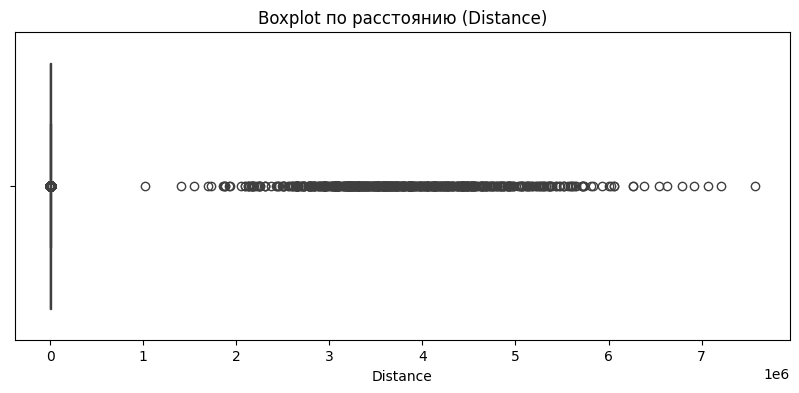

    Start Location  End Location   Distance   Duration
8         западная       озерная        3.0  17.366667
21      лермонтова        дружбы        5.0  29.433333
67          ленина      овражная        5.0  52.216667
70    строительная  строительная        4.0  17.900000
108      заводская     свердлова        4.0  33.466667
128     спортивная       свободы  4416111.0  29.966667
135        полевая    пионерская  6627165.0  49.450000
144      березовая       майская        4.0  37.350000
189        луговая         труда        4.0  42.383333
221   дзержинского     восточная        4.0  23.633333
Количество аномальных строк в Distance: 3514
Количество поездок с дистанцией меньше 100 м: 2923
Количество поездок с дистанцией более 10000 м: 591


In [15]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

anomalies_distance = df[(df['Distance'] <= 100) | (df['Distance'] > 10000)]
anomalies_count = anomalies_distance.shape[0]
print(anomalies_distance[['Start Location', 'End Location', 'Distance', 'Duration']].head(10))

low_distance_count = df[df['Distance'] < 100].shape[0]
high_distance_count = df[df['Distance'] > 10000].shape[0]

print(f"Количество аномальных строк в Distance: {anomalies_count}")
print(f"Количество поездок с дистанцией меньше 100 м: {low_distance_count}")
print(f"Количество поездок с дистанцией более 10000 м: {high_distance_count}")

Количество выбросов по каждому району:
Start District
центральный        917
юго-восточный      658
северо-западный    594
ленинский          539
октябрьский        479
заречный           338
Name: is_outlier, dtype: int64
Аномальных строк по условию Distance < 100: 2923
Аномальных строк по условию Distance > upper_bound: 607
Выбросы по Distance удалены.


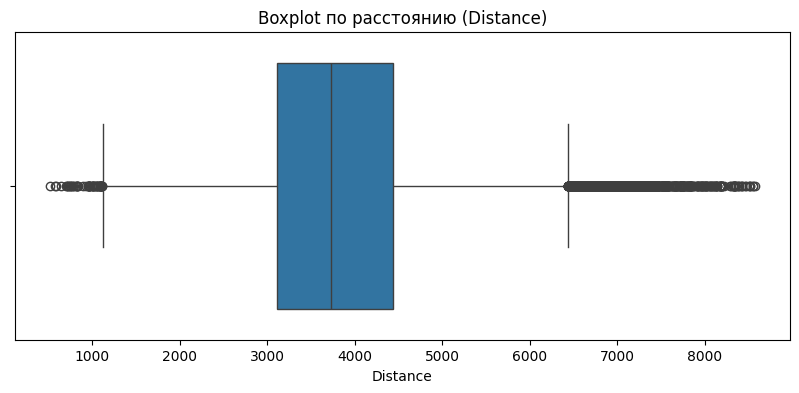

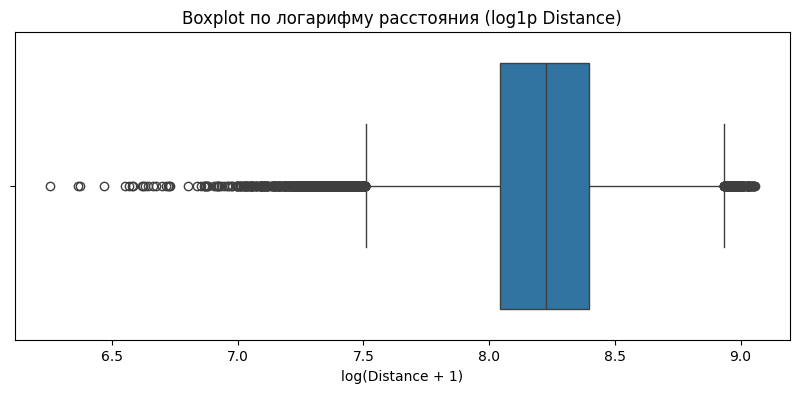

In [16]:
# Квартильные границы
q1 = df['Distance'].quantile(0.25)
q3 = df['Distance'].quantile(0.75)
iqr = q3 - q1

# Границы для определения выбросов
condition = (df['Distance'] < 100) & (df['Duration'] > 8)
upper_bound = q3 + 3 * iqr

df1 = df.copy()
df1['is_outlier'] = (condition) | (df1['Distance'] > upper_bound)
outliers_by_district = df1.groupby('Start District')['is_outlier'].sum()
print("Количество выбросов по каждому району:")
print(outliers_by_district.sort_values(ascending=False))

condition = (df['Distance'] < 100)
condition_large = (df['Distance'] > upper_bound)

print(f"Аномальных строк по условию Distance < 100: {condition.sum()}")
print(f"Аномальных строк по условию Distance > upper_bound: {condition_large.sum()}")

df = df[(df['Distance'] >= 100) & (df['Distance'] <= upper_bound)]

print("Выбросы по Distance удалены.")


plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Distance'])
plt.title("Boxplot по расстоянию (Distance)")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=np.log1p(df['Distance']))  # log1p = log(1 + x) для работы с нулями
plt.title("Boxplot по логарифму расстояния (log1p Distance)")
plt.xlabel("log(Distance + 1)")
plt.show()


- Удалено аномальных строк по условию Distance < 100: 2923
- Удалено Аномальных строк по условию Distance > upper_bound: 60
#####
Выбросы по Distance удалены.

**Почему могли возникнуть аномалии и такие выбросы?
** - GPS плохо работает в центре, поэтому не видно остановку самоката, следовательно время поездки увеличивается, не смотря на стоячее положение
** - По распределению пропусков видно, что в центре аномалий больше, что также можно приурочить к некорректной работе GPS**

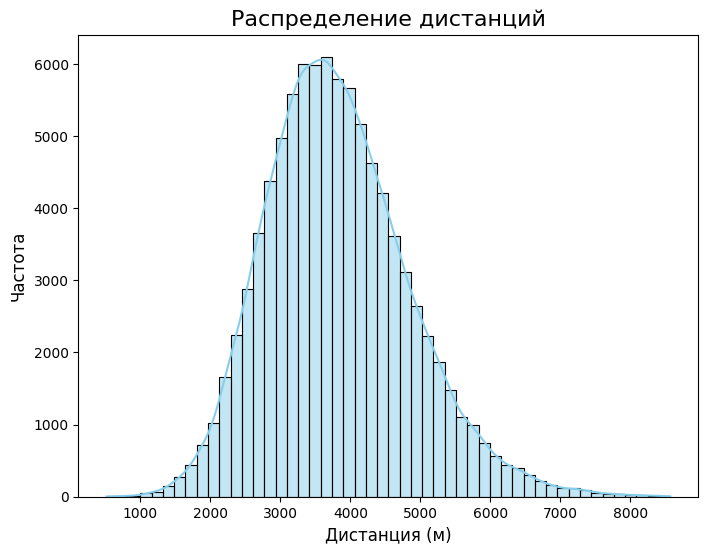

In [17]:
df = df[df['Distance'] <= 10000]
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

In [18]:
missing_end_date = df[df['End Date'].isna()]
print(f"Пропусков в 'End Date': {len(missing_end_date)}")

print(missing_end_date[['Start Date', 'End Date']].head(10))


Пропусков в 'End Date': 0
Empty DataFrame
Columns: [Start Date, End Date]
Index: []


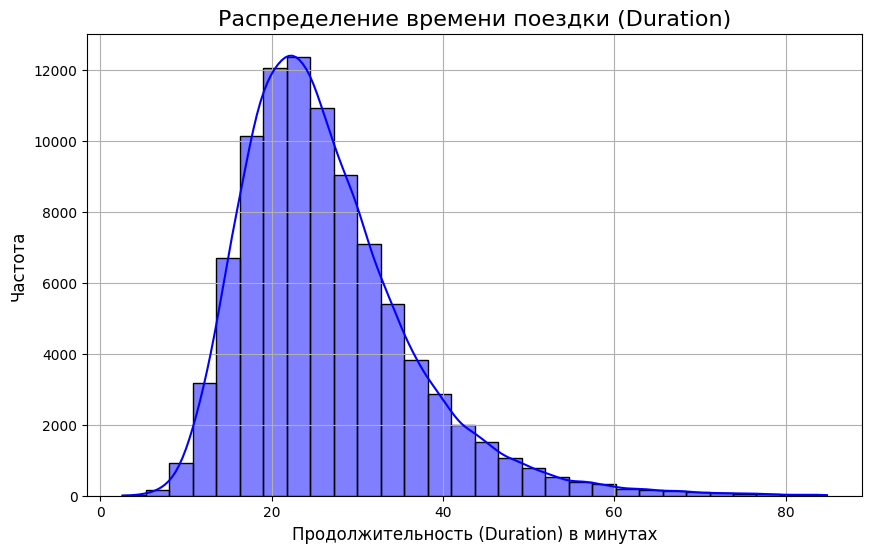

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Построение гистограммы распределения для столбца 'Duration'
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], kde=True, bins=30, color='blue')

# Настройки графика
plt.title('Распределение времени поездки (Duration)', fontsize=16)
plt.xlabel('Продолжительность (Duration) в минутах', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.grid(True)

# Показать график
plt.show()

# Нормализация данных в столбцах DataFrame df

**Добавляем в DataFrame df новые признаки (колонки), которые помогают глубже анализировать данные поездок: когда они происходили, как долго длились, с какой скоростью и в какое время суток.**

In [20]:
df['Start Month'] = df['Start Date'].dt.month
df['End Month'] = df['End Date'].dt.month

seasons = {
    12: 'Зима', 1: 'Зима', 2: 'Зима',
    3: 'Весна', 4: 'Весна', 5: 'Весна',
    6: 'Лето', 7: 'Лето', 8: 'Лето',
    9: 'Осень', 10: 'Осень', 11: 'Осень'
}

df['Start Season'] = df['Start Month'].map(seasons)
df['End Season'] = df['End Month'].map(seasons)

df['Time Start'] = df['Start Date'].dt.time
df['Time End'] = df['End Date'].dt.time

df['Duration'] = (df['End Date'] - df['Start Date']).dt.total_seconds() / 60

df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')
df['Speed (km/h)'] = (df['Distance'] / 1000) / (df['Duration'] / 60)

def time_day(x):
    if 5 <= x <= 12:
        return 'Утро'
    elif 12 < x <= 18:
        return 'День'
    elif 18 < x <= 22:
        return 'Вечер'
    return 'Ночь'

df['Time of Day'] = df['Start Date'].apply(lambda x: time_day(x.hour))
df.loc[:, 'Start Hour'] = df['Start Date'].dt.hour
df.loc[:, 'Day of Week'] = df['Start Date'].dt.day_name()
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:51:41,00:38:04,46.383333,8.364211


**Поиск и удаление дубликатов в DataFrame df, основываясь на дате начала поездки и районе отправления.**

In [21]:
duplicates = df[df.duplicated(subset=['Start Date', 'Start District'], keep=False)]
df = df.drop_duplicates(subset=['Start Date', 'Start District'], keep='first')
df

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,End Month,Start Season,End Season,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h)
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,4,Весна,Весна,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:45:06,00:06:55,21.816667,9.081131
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:46:01,00:25:35,39.566667,7.570008
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:48:04,00:09:21,21.283333,7.839937
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,8,Лето,Лето,Ночь,23,Monday,23:51:41,00:38:04,46.383333,8.364211


# Анализ факторов, влияющих на спрос, и визуализирует результаты. Он показывает когда (по сезонам, дням, часам) чаще всего происходят поездки, а также среднюю длительность поездок в зависимости от времени года

Start Season
Весна    26.393389
Лето     26.363113
Name: Duration, dtype: float64
Day of Week
Sunday       17131
Saturday     16981
Friday       13314
Monday       12035
Wednesday    11030
Thursday     10899
Tuesday      10567
Name: count, dtype: int64
Start Hour
0     1102
1      534
2      413
3      178
4      204
5      789
6     2322
7     3314
8     3757
9     3618
10    3504
11    3063
12    3433
13    3949
14    5000
15    5782
16    6693
17    7337
18    7748
19    8203
20    7705
21    5988
22    4565
23    2756
Name: count, dtype: int64


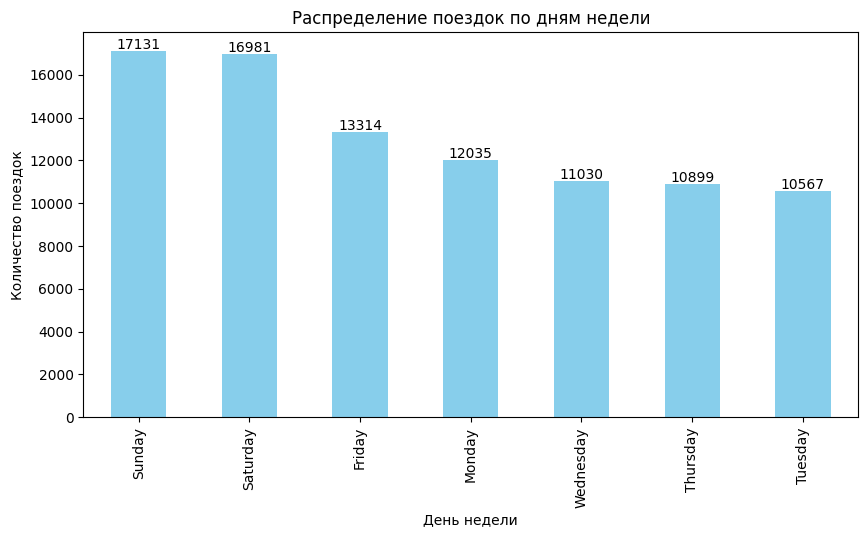

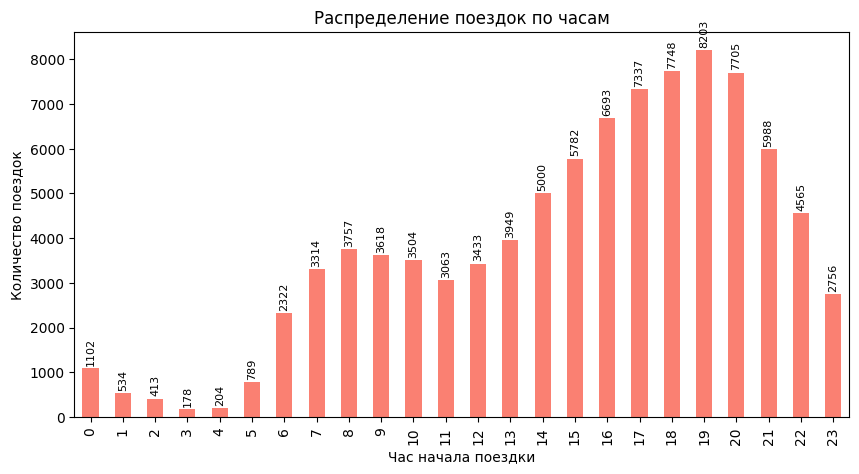

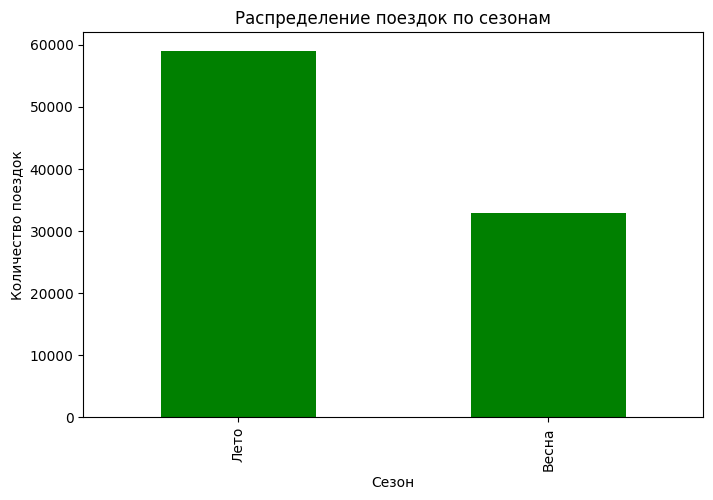

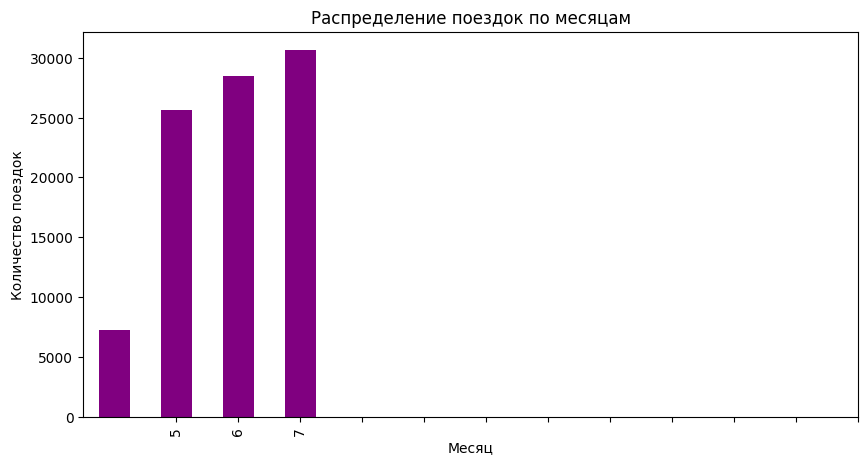

In [22]:
# Анализ факторов, влияющих на спрос
# 1. Средняя длительность поездки по сезонам
season_duration = df.groupby('Start Season')['Duration'].mean()
print(season_duration)

# 2. Количество поездок по дням недели
day_counts = df['Day of Week'].value_counts()
print(day_counts)

# 3. Количество поездок по часам
hour_counts = df['Start Hour'].value_counts().sort_index()
print(hour_counts)

# 4. Количество поездок по сезонам
season_counts = df['Start Season'].value_counts()

# 5. Количество поездок по месяцам
month_counts = df['Start Month'].value_counts().sort_index()

# Визуализация данных с аннотациями
plt.figure(figsize=(10, 5))
day_counts.plot(kind='bar', color='skyblue')
plt.xlabel('День недели')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по дням недели')
for i, v in enumerate(day_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=10)
plt.show()

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar', color='salmon')
plt.xlabel('Час начала поездки')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по часам')
for i, v in enumerate(hour_counts):
    plt.text(i, v + 100, str(v), ha='center', fontsize=8, rotation=90)
plt.show()

plt.figure(figsize=(8, 5))
season_counts.plot(kind='bar', color='green')
plt.xlabel('Сезон')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по сезонам')
plt.show()

plt.figure(figsize=(10, 5))
month_counts.plot(kind='bar', color='purple')
plt.xlabel('Месяц')
plt.ylabel('Количество поездок')
plt.title('Распределение поездок по месяцам')
plt.xticks(range(1, 13))
plt.show()




**Строим гистограмму распределения дистанций поездок**

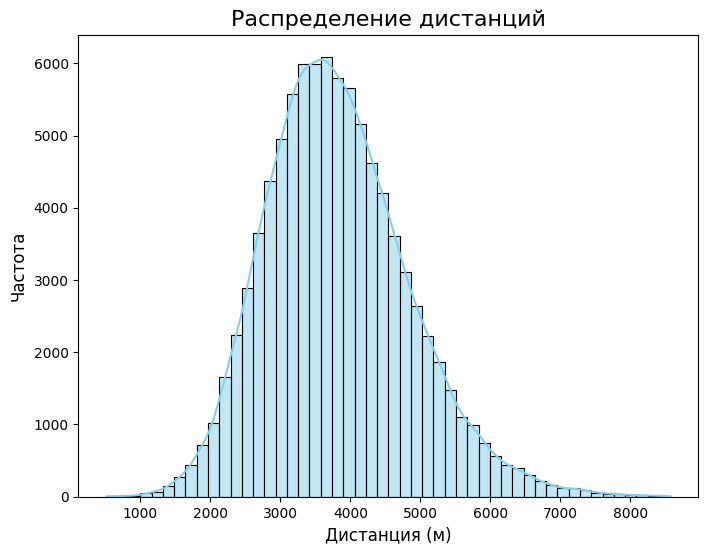

In [23]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Distance'], kde=True, color='skyblue', bins=50)

# Добавим подписи и заголовок
plt.title('Распределение дистанций', fontsize=16)
plt.xlabel('Дистанция (м)', fontsize=12)
plt.ylabel('Частота', fontsize=12)

# Показать график
plt.show()

# Рассчитываем стоимость каждой поездки на основе времени суток и дня недели, применяя динамическую тарифную сетку.

In [24]:
def get_rate(weekday, hour):
    if weekday < 5:  # Пн–Пт
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 5
        elif 16 <= hour < 22:
            return 6
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 5
    else:  # Сб–Вс
        if 1 <= hour < 6:
            return 3
        elif 6 <= hour < 10:
            return 4
        elif 10 <= hour < 16:
            return 6
        elif 16 <= hour < 22:
            return 7
        else:  # 22:00 – 01:00 (hour 22, 23, 0)
            return 6


df['Weekday'] = df['Start Date'].dt.weekday
df['Start Hour'] = df['Start Date'].dt.hour

df['Rate per Minute'] = df.apply(lambda row: get_rate(row['Weekday'], row['Start Hour']), axis=1)

df['Trip Cost'] = df['Duration'] * df['Rate per Minute']
df

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\1598019194.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Weekday'] = df['Start Date'].dt.weekday
C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\1598019194.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Start Hour'] = df['Start Date'].dt.hour
C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\1598019194.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Time of Day,Start Hour,Day of Week,Time Start,Time End,Duration,Speed (km/h),Weekday,Rate per Minute,Trip Cost
0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,Утро,9,Saturday,09:01:03,09:24:45,23.700000,10.301266,5,4,94.800000
1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,Утро,9,Saturday,09:01:07,09:29:32,28.416667,9.533138,5,4,113.666667
2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,Утро,9,Saturday,09:04:27,09:42:46,38.316667,7.077860,5,4,153.266667
3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,Утро,9,Saturday,09:06:34,09:38:23,31.816667,7.318806,5,4,127.266667
4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,Утро,9,Saturday,09:09:27,09:40:07,30.666667,7.882826,5,4,122.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102250,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,...,Ночь,23,Monday,23:45:06,00:06:55,21.816667,9.081131,0,5,109.083333
102251,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,...,Ночь,23,Monday,23:46:01,00:25:35,39.566667,7.570008,0,5,197.833333
102252,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,...,Ночь,23,Monday,23:48:04,00:09:21,21.283333,7.839937,0,5,106.416667
102253,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,...,Ночь,23,Monday,23:51:41,00:38:04,46.383333,8.364211,0,5,231.916667


**Столбчатая диаграмму (bar plot), показывающую распределение поездок по времени суток (Утро, День, Вечер, Ночь)**

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3707444050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Time of Day', data=df, palette='Set2')


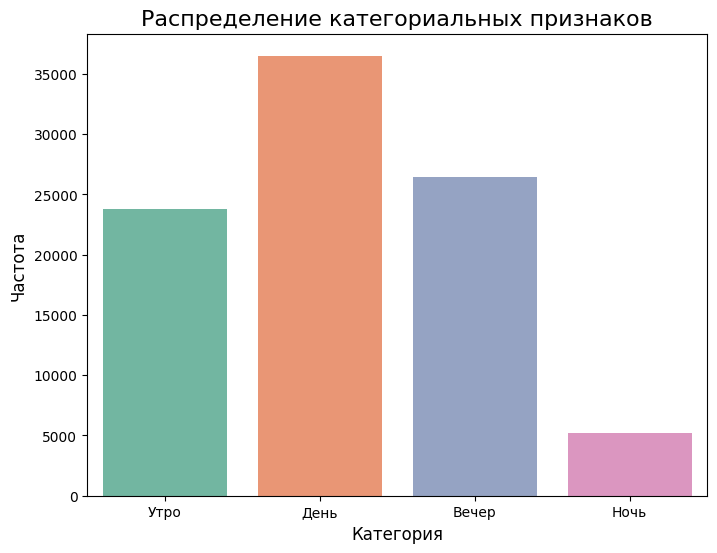

In [25]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Time of Day', data=df, palette='Set2')

plt.title('Распределение категориальных признаков', fontsize=16)
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Частота', fontsize=12)

plt.show()

**Анализ распределения поездок по районам в будние и выходные дни.**

In [26]:
df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')

district_day_type_distribution = (
    df.groupby(['Day Type', 'Start District'])
       .size()
       .reset_index(name='Количество поездок')
)

day_type_order = ['Будний день', 'Выходной']
district_day_type_distribution['Day Type'] = pd.Categorical(
    district_day_type_distribution['Day Type'],
    categories=day_type_order,
    ordered=True
)

district_day_type_distribution = (
    district_day_type_distribution
    .sort_values(by=['Day Type', 'Количество поездок'], ascending=[True, False])
    .reset_index(drop=True)
)

print(district_day_type_distribution)

       Day Type   Start District  Количество поездок
0   Будний день      центральный               15521
1   Будний день    юго-восточный               10914
2   Будний день        ленинский                9150
3   Будний день  северо-западный                9078
4   Будний день      октябрьский                7785
5   Будний день         заречный                5397
6      Выходной      центральный                8120
7      Выходной    юго-восточный                6555
8      Выходной        ленинский                5579
9      Выходной  северо-западный                5546
10     Выходной      октябрьский                4883
11     Выходной         заречный                3429


C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3282115783.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Day Type'] = df['Weekday'].apply(lambda x: 'Будний день' if x < 5 else 'Выходной')


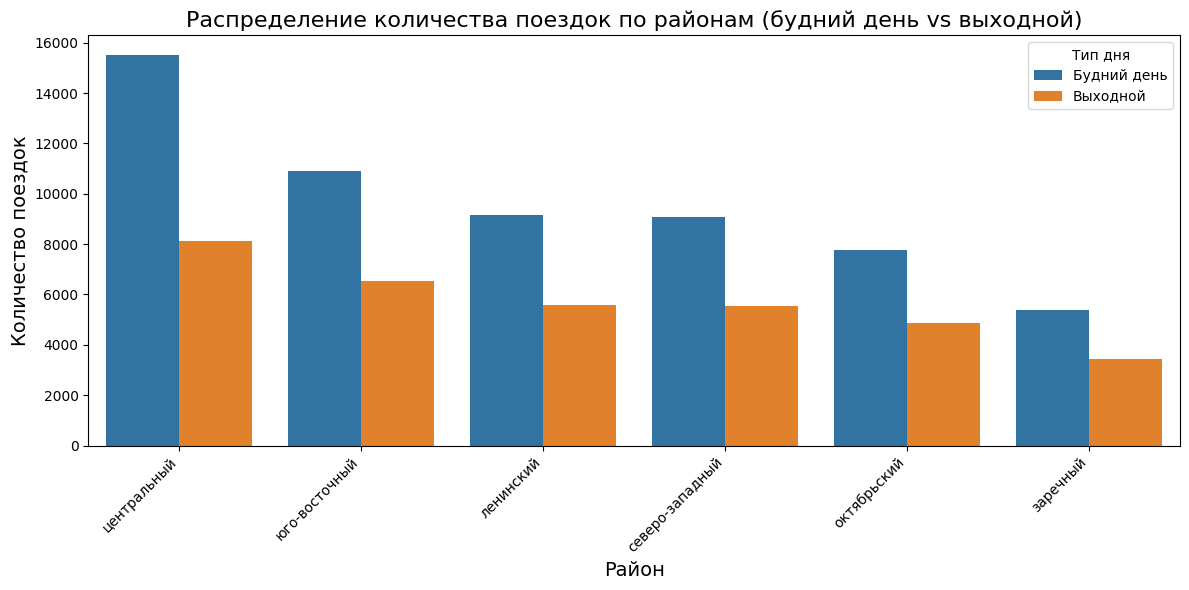

In [27]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Start District', y='Количество поездок', hue='Day Type', data=district_day_type_distribution)

plt.title('Распределение количества поездок по районам (будний день vs выходной)', fontsize=16)
plt.xlabel('Район', fontsize=14)
plt.ylabel('Количество поездок', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип дня')

plt.tight_layout()
plt.show()

**Два анализа: один — визуализирует распределение стоимости поездки по районам, а второй — рассчитывает среднюю продолжительность поездки по районам.**

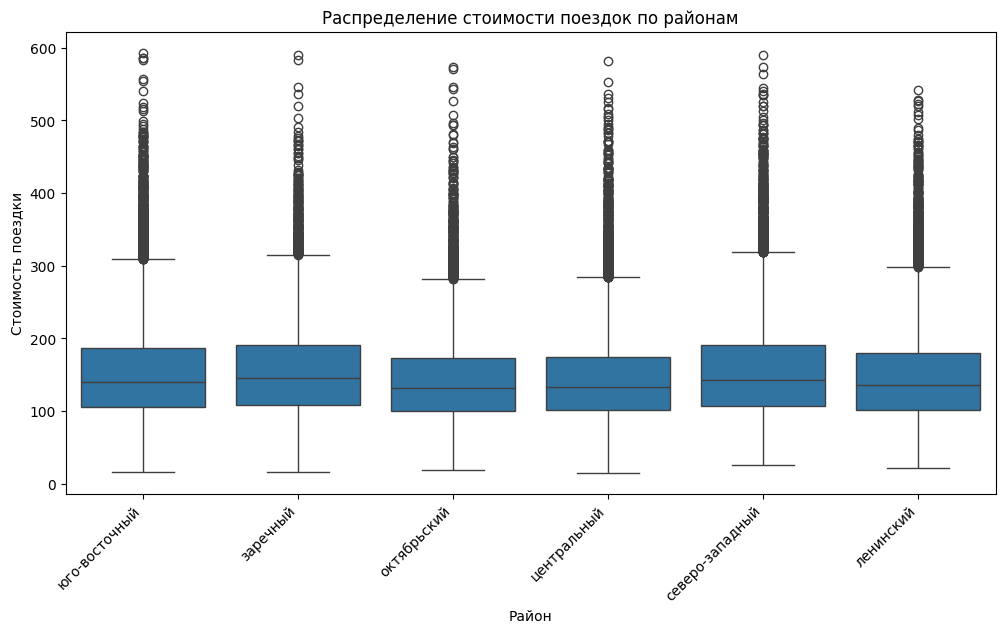

Start District
заречный           27.755395
северо-западный    27.680513
юго-восточный      27.184948
ленинский          26.141154
октябрьский        25.246027
центральный        25.200127
Name: Duration, dtype: float64


In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Start District', y='Trip Cost', data=df)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Район')
plt.ylabel('Стоимость поездки')
plt.title('Распределение стоимости поездок по районам')

plt.show()

average_duration_by_district = df.groupby('Start District')['Duration'].mean().sort_values(ascending=False)
print(average_duration_by_district)

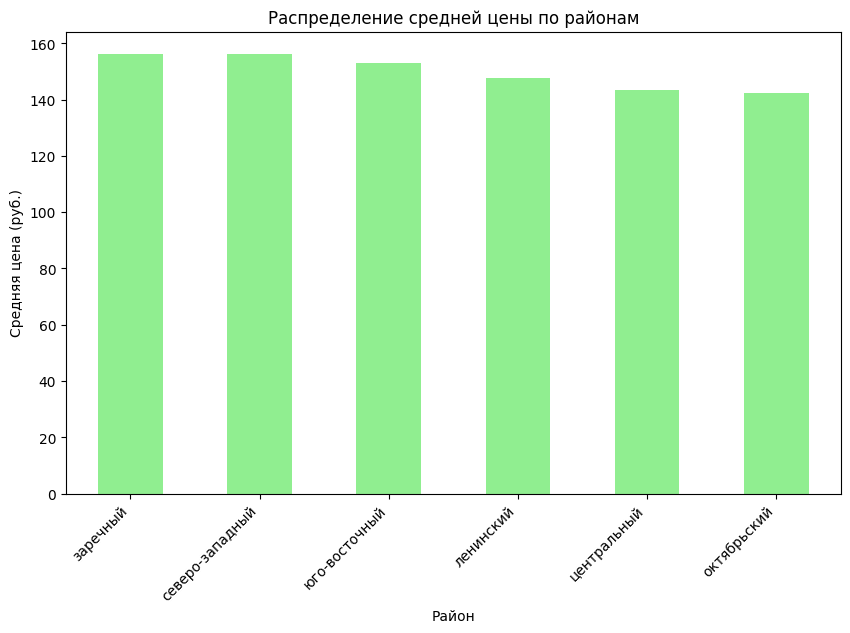

In [29]:
district_price = df.groupby('Start District')['Trip Cost'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
district_price.plot(kind='bar', color='lightgreen')
plt.xlabel('Район')
plt.ylabel('Средняя цена (руб.)')
plt.title('Распределение средней цены по районам')
plt.xticks(rotation=45, ha='right')
plt.show()

**Выведем несколько значений.
Среднее значение стоимости поездки:
Максимальное значение стоимости поездки:
Медиану стоимости поездки:**


In [30]:
print(df['Trip Cost'].mean())
print(df['Trip Cost'].max())
print(df['Trip Cost'].median())

149.11670672161992
593.3666666666667
137.31666666666666


График для отображения средней продолжительности поездки по различным районам, чтобы наглядно сравнить, где поездки в среднем длительнее, а где короче.

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\615108698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")


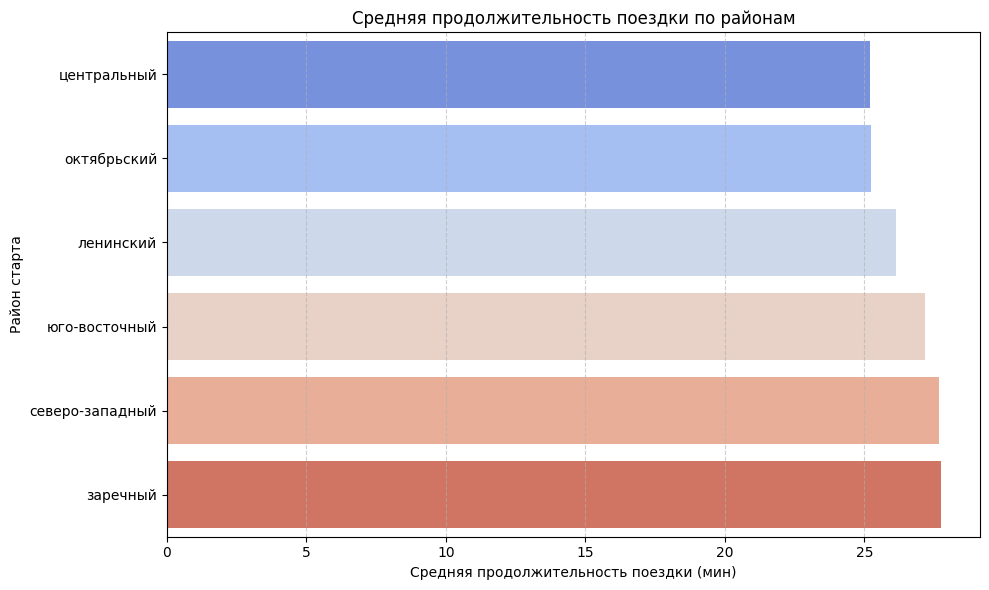

In [31]:
district_durations = df.groupby("Start District")["Duration"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=district_durations.values, y=district_durations.index, palette="coolwarm")
plt.xlabel("Средняя продолжительность поездки (мин)")
plt.ylabel("Район старта")
plt.title("Средняя продолжительность поездки по районам")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Тепловая карта для визуализации распределения количества поездок по часам дня и районам старта.
-Группировка данных по району старта и часу:
-Сортировка районов по убыванию количества поездок:
-Создание сводной таблицы (pivot table):
-Сортировка таблицы по убыванию количества поездок в районах:
-Построение тепловой карты (Heatmap):
-Настройки графика:**

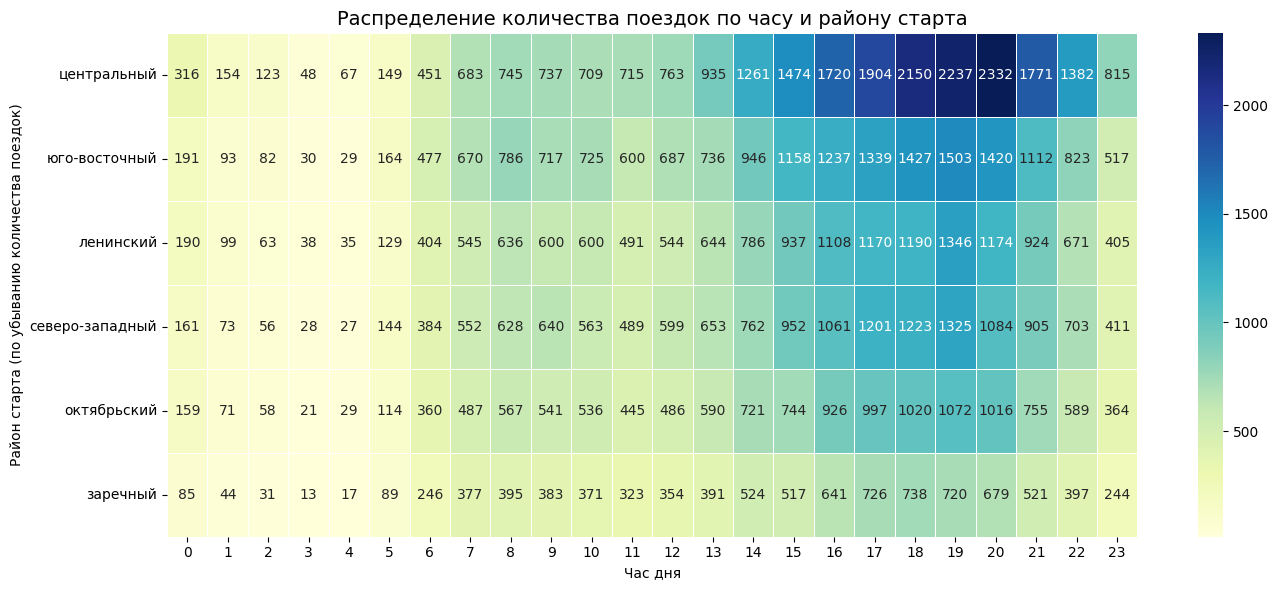

In [32]:
grouped = df.groupby(['Start District', 'Start Hour']).size().reset_index(name='Trip Count')
district_order = df['Start District'].value_counts().index.tolist()
pivot_table = grouped.pivot(index='Start District', columns='Start Hour', values='Trip Count').fillna(0)

pivot_table = pivot_table.reindex(district_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=.5)
plt.title("Распределение количества поездок по часу и району старта", fontsize=14)
plt.xlabel("Час дня")
plt.ylabel("Район старта (по убыванию количества поездок)")
plt.tight_layout()
plt.show()

**Два графика: boxplot (ящик с усами) и histplot (гистограмма) для колонки Distance (расстояние). Графики отображаются на одном холсте с использованием подграфиков (subplots).**

C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\SIDov\AppData\Local\Programs\Python\Python310\

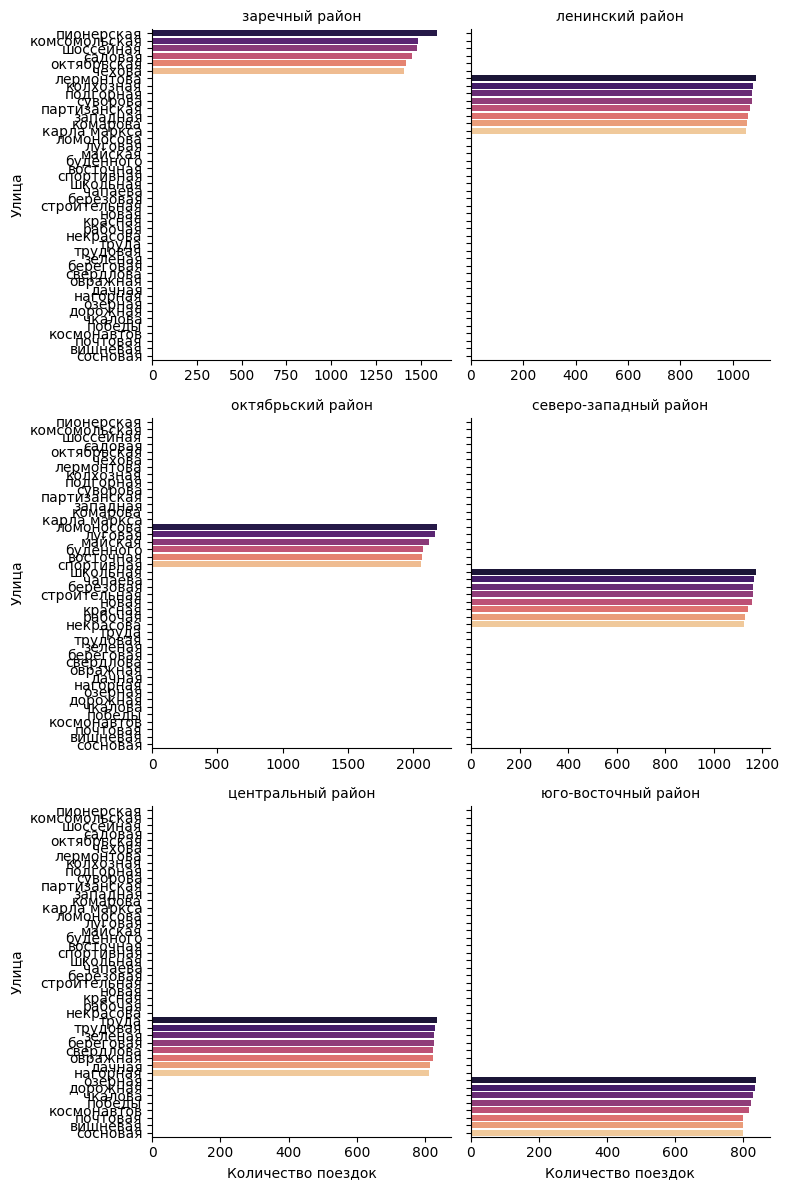

In [33]:
street_distribution = df.groupby(['Start District', 'Start Location']).size().reset_index(name='Поездок')

street_distribution = street_distribution.sort_values(['Start District', 'Поездок'], ascending=[True, False])
g = sns.FacetGrid(
    street_distribution.groupby('Start District').head(8),  # Топ улиц на район
    col='Start District', col_wrap=2, height=4, sharex=False
)
g.map_dataframe(sns.barplot, x='Поездок', y='Start Location', palette='magma')
g.set_titles(col_template="{col_name} район")
g.set_axis_labels("Количество поездок", "Улица")
plt.tight_layout()
plt.show()

**Гистограммы (barplot) для визуализации распределения количества поездок по улицам в разных районах, используя библиотеку Seaborn и FacetGrid для создания нескольких подграфиков (facet plots).**

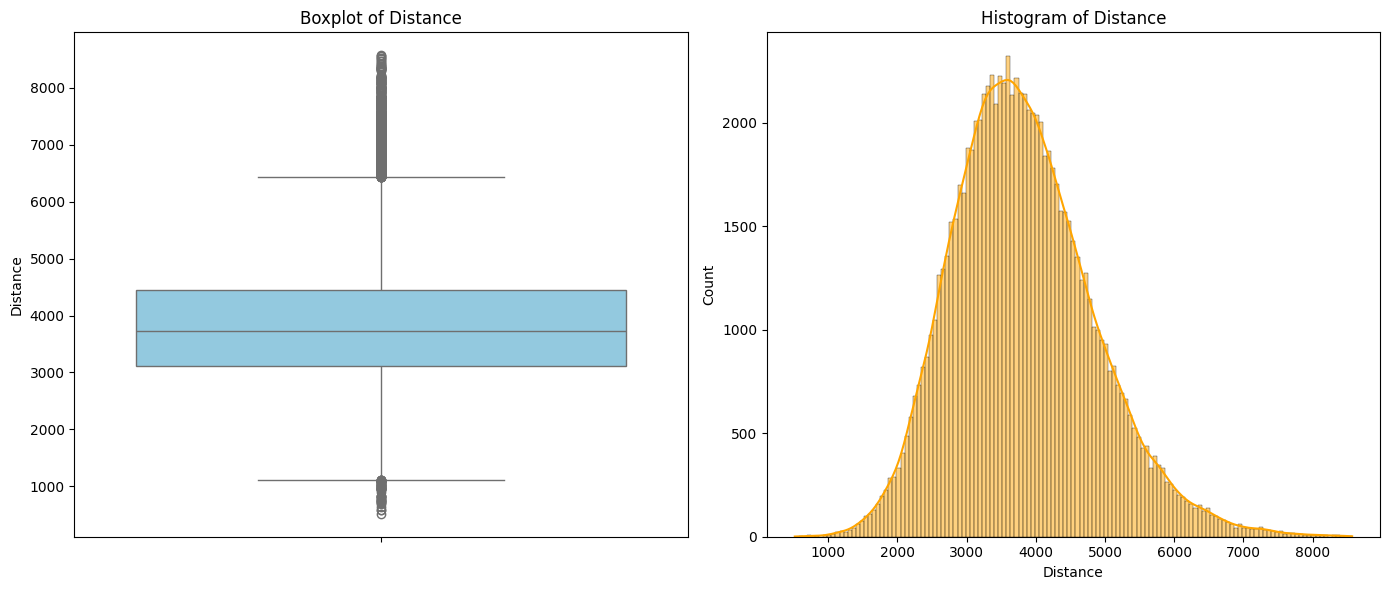

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot (вертикальный)
sns.boxplot(y=df['Distance'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Distance')

# Histplot
sns.histplot(df['Distance'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Histogram of Distance')

plt.tight_layout()
plt.show()

# Предобработка погоды

In [40]:
w = w.iloc[1:]

In [42]:
w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
w['Cloud Cover Total'] = w['Cloud Cover Total'].fillna(method='ffill')
w['Sunshine Duration'] = w['Sunshine Duration'].fillna(method='ffill')
w['Datetime'] = w['Datetime'].dropna()

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3957094709.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3957094709.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w['Precipitation Total'] = w['Precipitation Total'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3957094709.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  w['Wind Speed'] = w['Wind Speed'].fillna(method='ffill')
C:\Users\SIDov\AppData\Local\Tem

In [45]:
def time_of_the_year(x):
    d = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter',
    }
    return d[x]
dw = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

w['Datetime'] = pd.to_datetime(w['Datetime'])
w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\367895995.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w['Datetime'] = pd.to_datetime(w['Datetime'])
C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\367895995.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  w['Time of the year'] = w['Datetime'].apply(lambda x: time_of_the_year(x.month))


In [46]:
test_df = w[w['Temperature'].isna()]  # Строки, где Temperature == NaN
train_df = w[w['Temperature'].notna()]  # Строки, где Temperature не NaN

In [47]:
train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')
train_df = train_df[train_df['Precipitation Total'] < 3]

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\1466324480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Precipitation Total'] = train_df['Precipitation Total'].astype('float')


In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [49]:
df_ohe = pd.get_dummies(train_df, columns=['Time of the year'], prefix='Category')

In [50]:
df_ohe['Category_Summer'] = df_ohe['Category_Summer'].astype('float')
df_ohe['Category_Spring'] = df_ohe['Category_Spring'].astype('float')

In [51]:
df_ohe = df_ohe.drop(columns=['Datetime'])

In [52]:
df_ohe.isna().sum()

Temperature            0
Precipitation Total    0
Wind Gust              0
Wind Speed             0
Cloud Cover Total      0
Sunshine Duration      0
Category_Spring        0
Category_Summer        0
dtype: int64

In [54]:
X = df_ohe[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']]  # Признаки (вектора)
y = df_ohe['Temperature']  # Целевой признак (то, что нужно предсказать)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

model = CatBoostRegressor(iterations=10000,  # Максимальное количество итераций
                          learning_rate=0.1,  # Коэффициент обучения
                          depth=6,  # Глубина деревьев
                          cat_features=[],  # Список категориальных признаков (если есть)
                          verbose=200,  # Печать прогресса
                          early_stopping_rounds=50)  # Останавливаем обучение, если ошибка не улучшается в течение 50 раундов

# Обучение модели с валидацией на валидационном наборе
model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Прогнозирование
y_pred = model.predict(X_test)

# Оценка модели
mse = mean_squared_error(y_test, y_pred)
print(f"Среднеквадратичная ошибка (MSE) на тестовых данных: {mse}")

0:	learn: 6.4177160	test: 6.5217056	best: 6.5217056 (0)	total: 162ms	remaining: 26m 59s
200:	learn: 3.2171956	test: 3.8320557	best: 3.8290882 (192)	total: 744ms	remaining: 36.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3.822270472
bestIteration = 293

Shrink model to first 294 iterations.
Среднеквадратичная ошибка (MSE) на тестовых данных: 14.609751665101168


In [56]:
df_ohe1 = pd.get_dummies(test_df, columns=['Time of the year'], prefix='Category')
df_ohe1['Category_Summer'] = df_ohe1['Category_Summer'].astype('float')
df_ohe1['Category_Spring'] = df_ohe1['Category_Spring'].astype('float')
y_pred1 = model.predict(df_ohe1[['Precipitation Total', 'Wind Gust', 'Wind Speed', 'Cloud Cover Total', 'Sunshine Duration', 'Category_Spring', 'Category_Summer']])
test_df['Temperature'] = y_pred1

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\1961874598.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Temperature'] = y_pred1


In [57]:
test_df

,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
363,2023-04-16 02:00:00,9.200621,0.3,13.32,3.671294,100,0,Spring
364,2023-04-16 03:00:00,9.708689,0.4,13.32,4.452954,98,0,Spring
365,2023-04-16 04:00:00,8.903787,0.4,13.32,4.802999,100,0,Spring
366,2023-04-16 05:00:00,8.830492,0.3,13.679999,4.379589,100,0,Spring
367,2023-04-16 06:00:00,8.999679,0.2,14.4,5.0528407,100,0,Spring
368,2023-04-16 07:00:00,8.504952,0.3,15.4800005,6.379216,100,0,Spring
369,2023-04-16 08:00:00,9.763513,0.2,19.08,9.957108,100,0,Spring
370,2023-04-16 09:00:00,10.839634,0.2,24.48,10.383987,100,0,Spring
371,2023-04-16 10:00:00,11.493023,0.2,24.48,7.7043357,100,0,Spring
372,2023-04-16 11:00:00,12.649885,0.3,24.84,8.534353,91,4.8484864,Spring


In [58]:
test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))
train_df['Datetime'] = train_df['Datetime'].apply(lambda x: pd.to_datetime(x))

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\3117978878.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['Datetime'] = test_df['Datetime'].apply(lambda x: pd.to_datetime(x))


In [59]:
w1 = pd.concat([train_df, test_df])  # Можно выбрать тип слияния: 'inner', 'outer', 'left', 'right'

In [61]:
from IPython.display import clear_output


def find_nearest_date(date1, df2):
    diff1 = abs(df2['Datetime'] - date1).idxmin()
    clear_output(wait=True)
    print(date1)
    return df2.loc[diff1]

# Создаем новый DataFrame для хранения результата
merged_rows = []

# Для каждой строки в df1 находим ближайшую дату в df2
for _, row in df.iterrows():
    nearest_row = find_nearest_date(row['Start Date'], w1)
    # Объединяем строки по найденной ближайшей дате
    merged_row = pd.concat([row, nearest_row], axis=0)
    merged_rows.append(merged_row)

# Преобразуем список строк в DataFrame
df = pd.DataFrame(merged_rows)
df

2023-07-31 23:57:01


,Id,Start Date,End Date,Start Location,Start District,End Location,End District,Distance,Promo,Start Month,...,Trip Cost,Day Type,Datetime,Temperature,Precipitation Total,Wind Gust,Wind Speed,Cloud Cover Total,Sunshine Duration,Time of the year
Unnamed 0,100340,2023-04-22 09:01:03,2023-04-22 09:24:45,шевченко,юго-восточный,майская,октябрьский,4069.0,0,4,...,94.800000,Выходной,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 1,100341,2023-04-22 09:01:07,2023-04-22 09:29:32,чехова,заречный,спортивная,октябрьский,4515.0,0,4,...,113.666667,Выходной,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 2,100342,2023-04-22 09:04:27,2023-04-22 09:42:46,буденного,октябрьский,суворова,ленинский,4520.0,0,4,...,153.266667,Выходной,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 3,100343,2023-04-22 09:06:34,2023-04-22 09:38:23,труда,центральный,рабочая,северо-западный,3881.0,0,4,...,127.266667,Выходной,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
Unnamed 4,100344,2023-04-22 09:09:27,2023-04-22 09:40:07,первомайская,северо-западный,юбилейная,юго-восточный,4029.0,0,4,...,122.666667,Выходной,2023-04-22 09:00:00,13.850245,0.0,20.16,6.2145634,71,16.969696,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Unnamed 91951,197707,2023-07-31 23:45:06,2023-08-01 00:06:55,озерная,юго-восточный,первомайская,северо-западный,3302.0,0,7,...,109.083333,Будний день,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 91952,197708,2023-07-31 23:46:01,2023-08-01 00:25:35,мичурина,ленинский,садовая,заречный,4992.0,0,7,...,197.833333,Будний день,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 91953,197709,2023-07-31 23:48:04,2023-08-01 00:09:21,лермонтова,ленинский,куйбышева,центральный,2781.0,0,7,...,106.416667,Будний день,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer
Unnamed 91954,197710,2023-07-31 23:51:41,2023-08-01 00:38:04,рябиновая,северо-западный,энергетиков,юго-восточный,6466.0,0,7,...,231.916667,Будний день,2023-08-01 00:00:00,21.140245,0.0,27,8.217153,97,0,Summer


In [62]:
df = df.reset_index(drop=True)

In [83]:
df['weekday'] = df['Start Date'].dt.weekday

In [84]:
df['Days'] = df['Start Date'].apply(lambda x: x.day)

# 1.Итоговая стоимость

In [76]:
# Преобразуем дату и создадим колонку только с датой
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['Date'] = df['Start Date'].dt.date

# Количество отъездов из каждой точки по датам
out_df = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')

# Количество приездов в каждую точку по датам
in_df = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем колонки для объединения
out_df.rename(columns={'Start Location': 'Location'}, inplace=True)
in_df.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем и считаем net_change
point_net = pd.merge(in_df, out_df, on=['Date', 'Location'], how='outer').fillna(0)
point_net['net_change'] = point_net['inflow'] - point_net['outflow']

# Сортировка и накопление
point_net.sort_values(['Location', 'Date'], inplace=True)
point_net['cumsum'] = point_net.groupby('Location')['net_change'].cumsum()


In [77]:
required_scooters = point_net.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)
required_scooters = required_scooters.sort_values(by='Required Scooters', ascending=False)
print(required_scooters)


        Location  Required Scooters
72    спортивная              141.0
52  первомайская              104.0
39          мира               91.0
37     матросова               87.0
31        ленина               85.0
..           ...                ...
63       садовая               -3.0
21     колхозная               -3.0
51  партизанская               -4.0
22      комарова               -5.0
59       пушкина               -5.0

[91 rows x 2 columns]


# 2.1 Определить топ-3 точки с самым высоким

In [104]:
from tqdm import tqdm
df['DateOnly'] = df['Datetime'].dt.date

# Теперь можно сгруппировать по дате
gbd = df.groupby('DateOnly')
list_data = []
for date, group in gbd:
    list_data.append([date, group])


In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
average_samokat = []
for i in list_data:
    da = [i[0]]
    datafr = i[1]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = first.merge(second, on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat.append(da)

def union_all_data(x):
    h = x[0]
    for k in range(len(x)):
        h = pd.concat([h, x[k]])
    return h

all_trafic = union_all_data(list(map(lambda x: x[1], average_samokat)))
all_trafic = all_trafic.groupby('Start Location')[['inter', 'leave', 'turn_per_day']].agg('sum').sort_values(by='turn_per_day', ascending=False)

In [106]:
all_trafic

,inter,leave,turn_per_day
Start Location,,,
ломоносова,2193,2154,4347
луговая,2182,2144,4326
спортивная,2075,2230,4305
майская,2150,2138,4288
буденного,2094,2168,4262
...,...,...,...
гоголя,751,791,1542
мира,732,805,1537
степная,778,753,1531


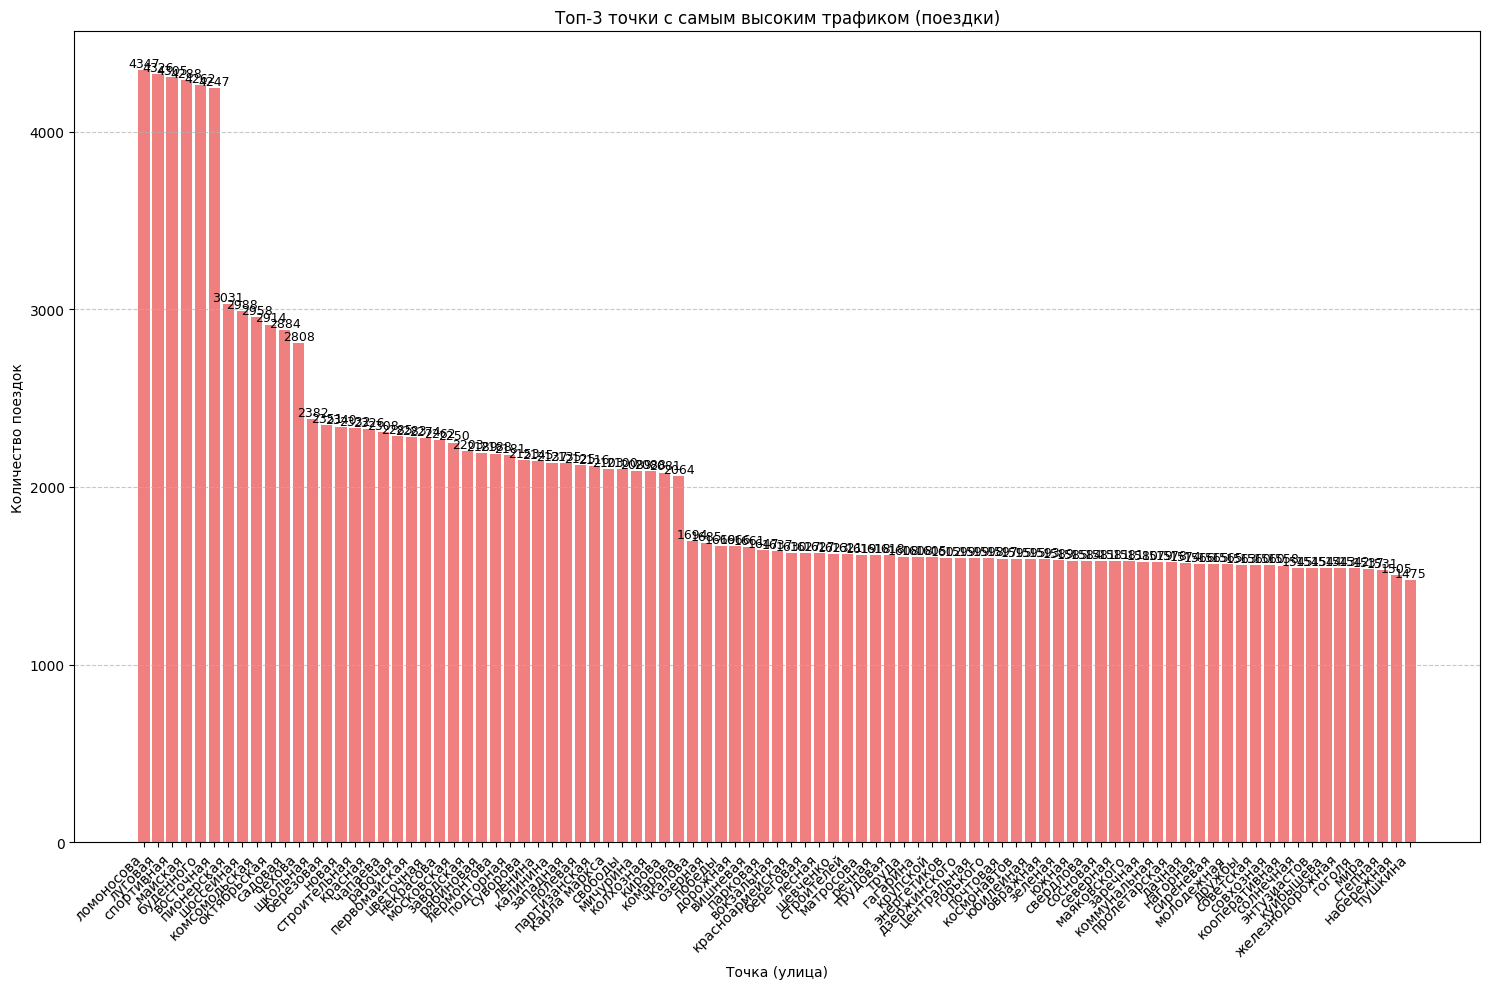

In [107]:
import matplotlib.pyplot as plt
# Строим график
plt.figure(figsize=(15, 10))
bars = plt.bar(all_trafic.index, all_trafic['turn_per_day'], color='lightcoral')

# Подписи на столбиках
for bar in bars:
    height = bar.get_height()  # Получаем высоту столбика (это количество поездок для конкретной локации)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=9)  # Размещаем текст в центре столбика

# Оформление
plt.title('Топ-3 точки с самым высоким трафиком (поездки)')
plt.xlabel('Точка (улица)')
plt.ylabel('Количество поездок')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Отображение графика
plt.show()


**Стоит ли закрывать некоторые точки?**

In [113]:
weekdays = {}

# tqdm добавляет прогресс-бар к итерации
for i in tqdm(list_data, desc="Обработка данных по дням недели"):
    f = dict(tuple(i[1].groupby('weekday')))
    ind = list(set(f.keys()))
    for k in ind:
        h = f[k]
        h = h[h['Start Season'] == 'Весна']
        if isinstance(weekdays.get(k, 0), int):
            weekdays[k] = h
        else:
            weekdays[k] = pd.concat([weekdays[k], h])

average_samokat_to_weekdays = []
for i in weekdays.keys():
    da = [i]
    datafr = weekdays[i]
    first = datafr['Start Location'].value_counts().to_frame()
    second = datafr['End Location'].value_counts().to_frame()
    third = datafr.groupby('Start Location')['Trip Cost'].agg('sum').to_frame()
    second.columns = ['leave']
    first.columns = ['inter']
    second.index.name = 'Start Location'
    fin = third.merge(first.merge(second, on='Start Location'), on='Start Location')
    fin['turn_per_day'] = fin['inter'] + fin['leave']
    da.append(fin.sort_values(by='turn_per_day', ascending=False))
    average_samokat_to_weekdays.append(da)

dat = average_samokat_to_weekdays[0][1]
for i in average_samokat_to_weekdays[1:]:
    dat += i[1]

Обработка данных по дням недели: 100%|███████████████████████████████████████████████| 102/102 [00:01<00:00, 65.10it/s]


In [114]:
dat = dat.sort_values(by='Trip Cost', ascending=False)
dat

,Trip Cost,inter,leave,turn_per_day
Start Location,,,,
луговая,112551.033333,776,723,1499
восточная,109311.650000,761,769,1530
ломоносова,107210.683333,763,748,1511
буденного,106395.333333,738,790,1528
спортивная,102939.266667,713,791,1504
...,...,...,...,...
набережная,37412.066667,268,268,536
матросова,37311.950000,268,306,574
строителей,37276.933333,255,295,550


In [115]:
popular = dat.index[:10] # Топ-10 самых популярных улиц

In [116]:
un_popular = dat.index[-10:] # Топ-10 самых непопулярных улиц

In [117]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [118]:
un_popular

Index(['сиреневая', 'советская', 'дружбы', 'дзержинского', 'пролетарская',
       'набережная', 'матросова', 'строителей', 'мира', 'гоголя'],
      dtype='object', name='Start Location')

In [119]:
sum(dat['Trip Cost'][:])

4924698.383333332

In [120]:
sum(dat['Trip Cost'][:19])

1606893.8

In [121]:
sum(dat['Trip Cost'][-19:])

725989.8666666666

In [123]:
(sum(dat['Trip Cost'][:19]) / sum(dat['Trip Cost'][:])) * 100

32.62928356055701

In [125]:
(sum(dat['Trip Cost'][-19:]) / sum(dat['Trip Cost'][:])) * 100

14.741813815920905

In [126]:
def get_arrival_sources_summary(df):
    # Все уникальные конечные локации
    end_locations = df['End Location'].unique()
    
    summary_dict = {}

    for end_loc in end_locations:
        # Фильтруем только поездки, заканчивающиеся в этой точке
        arrivals = df[df['End Location'] == end_loc]
        
        # Группируем по Start Location и считаем поездки
        grouped = arrivals.groupby('Start Location').size().reset_index(name='trips')
        
        # Считаем долю от общего количества
        total = grouped['trips'].sum()
        grouped['percent'] = (grouped['trips'] / total * 100).round(1)
        
        # Сортируем по убыванию
        grouped = grouped.sort_values(by='trips', ascending=False).reset_index(drop=True)
        
        summary_dict[end_loc] = grouped

    return summary_dict

arrival_summary_by_end_location = get_arrival_sources_summary(merged_df)


In [127]:
popular

Index(['луговая', 'восточная', 'ломоносова', 'буденного', 'спортивная',
       'майская', 'пионерская', 'садовая', 'шоссейная', 'комсомольская'],
      dtype='object', name='Start Location')

In [129]:
grouped_streets_by_district = merged_df.groupby('Start District')['Start Location'].unique().to_frame()
grouped_streets_by_district = pd.DataFrame(grouped_streets_by_district)
grouped_streets_by_district['1'] = grouped_streets_by_district['Start Location'].apply(len)
reversed_dict = {}
for k, v in grouped_streets_by_district.drop(columns=['1']).to_dict()['Start Location'].items():
    for v1 in v:
        reversed_dict[v1] = k

In [130]:
for i in popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

луговая
  Start Location  trips  percent         district
0      восточная     57      2.7      октябрьский
1        луговая     52      2.5      октябрьский
2        майская     48      2.3      октябрьский
3      буденного     43      2.0      октябрьский
4     пионерская     39      1.8         заречный
5        садовая     39      1.8         заречный
6     ломоносова     39      1.8      октябрьский
7    октябрьская     37      1.7         заречный
8       школьная     37      1.7  северо-западный
9     спортивная     35      1.6      октябрьский
восточная
  Start Location  trips  percent     district
0     спортивная     56      2.6  октябрьский
1     пионерская     53      2.5     заречный
2     ломоносова     48      2.2  октябрьский
3      восточная     46      2.1  октябрьский
4        майская     46      2.1  октябрьский
5        луговая     43      2.0  октябрьский
6      буденного     42      2.0  октябрьский
7  комсомольская     40      1.9     заречный
8         ленина  

In [131]:
for i in un_popular:
    print(i)
    n = arrival_summary_by_end_location[i]
    n['district'] = n['Start Location'].apply(lambda x: reversed_dict[x])
    print(n.head(10))

сиреневая
  Start Location  trips  percent         district
0     спортивная     22      2.8      октябрьский
1     ломоносова     21      2.6      октябрьский
2      буденного     20      2.5      октябрьский
3        майская     16      2.0      октябрьский
4      восточная     16      2.0      октябрьский
5          новая     16      2.0  северо-западный
6         чехова     16      2.0         заречный
7     пионерская     15      1.9         заречный
8       комарова     15      1.9        ленинский
9        луговая     14      1.8      октябрьский
советская
  Start Location  trips  percent         district
0     ломоносова     20      2.6      октябрьский
1        майская     19      2.5      октябрьский
2     спортивная     18      2.3      октябрьский
3        луговая     17      2.2      октябрьский
4         чехова     15      2.0         заречный
5    октябрьская     13      1.7         заречный
6       мичурина     13      1.7        ленинский
7       западная     13      1

In [135]:
for j in popular:
    print(reversed_dict[j])

октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
октябрьский
заречный
заречный
заречный
заречный


In [136]:
for j in un_popular:
    print(reversed_dict[j])

юго-восточный
центральный
центральный
центральный
центральный
центральный
центральный
центральный
центральный
центральный


**Вывод**: не стоит закрывать не одну точку, так как каждая делает свой достаточный вклад в общую сумму выручки.

**Самые популярные направления перемещения**

In [137]:
# Считаем количество поездок для каждой пары (маршрута)
route_counts = merged_df.groupby(['Start Location', 'End Location']).size().reset_index(name='trips')

# Сортируем по убыванию количества
most_popular_route = route_counts.sort_values(by='trips', ascending=False)

# Выводим результат
start = most_popular_route['Start Location']
end = most_popular_route['End Location']
count = most_popular_route['trips']

most_popular_route.head(10)

,Start Location,End Location,trips
3256,луговая,спортивная,66
184,буденного,буденного,64
3347,майская,спортивная,60
490,восточная,луговая,57
6555,спортивная,восточная,56
6586,спортивная,майская,55
3165,ломоносова,спортивная,55
3277,майская,буденного,54
489,восточная,ломоносова,53
4827,пионерская,восточная,53


**Есть ли необходимость перераспределять самокаты в конце дня?**

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\2721133280.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')


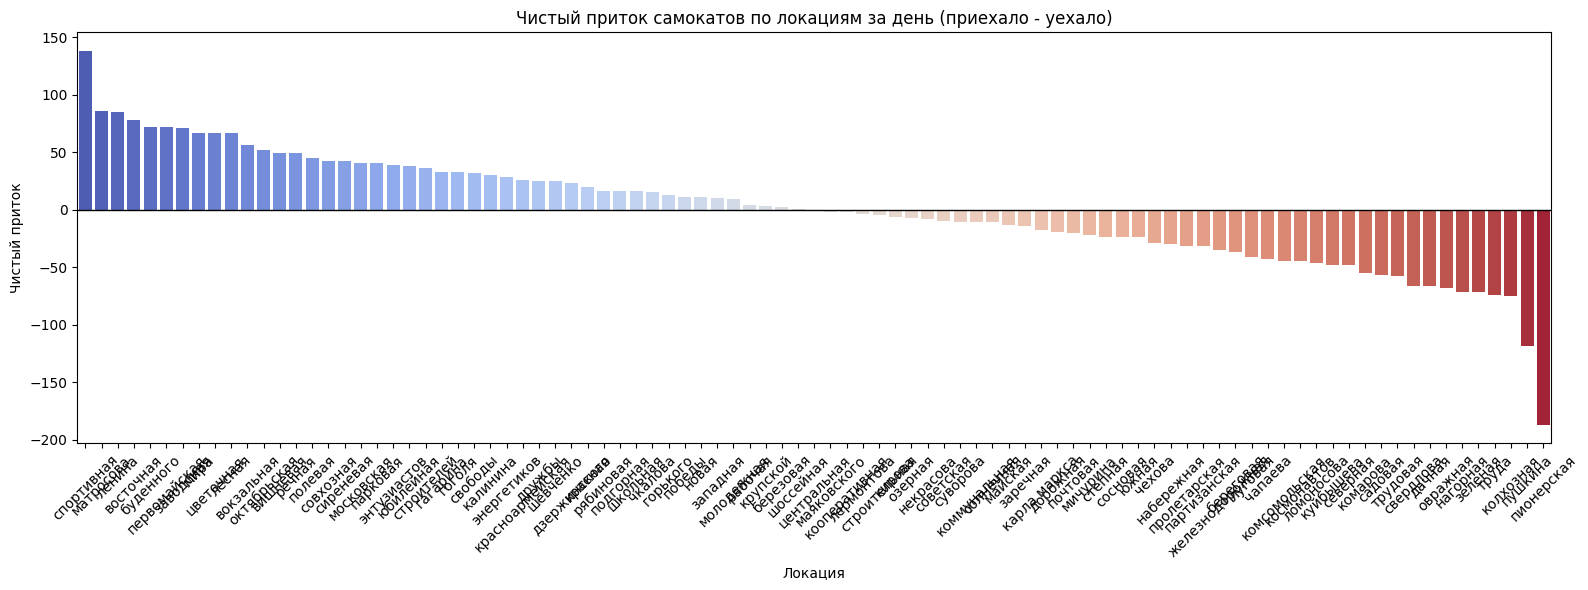

In [138]:
departures = merged_df.groupby('Start Location').size().reset_index(name='departures')
arrivals = merged_df.groupby('End Location').size().reset_index(name='arrivals')

# Объединяем данные
balance = pd.merge(arrivals, departures,
                   left_on='End Location', right_on='Start Location',
                   how='outer')

# Заполняем пропуски нулями (если в локации были только приезды или только уезды)
balance['End Location'] = balance['End Location'].combine_first(balance['Start Location'])
balance = balance.drop(columns=['Start Location'])
balance = balance.rename(columns={'End Location': 'Location'})
balance['arrivals'] = balance['arrivals'].fillna(0)
balance['departures'] = balance['departures'].fillna(0)

# Считаем чистый приток
balance['net_flow'] = balance['arrivals'] - balance['departures']

# Сортировка по притоку
balance = balance.sort_values(by='net_flow', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=balance, x='Location', y='net_flow', palette='coolwarm')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45)
plt.title('Чистый приток самокатов по локациям за день (приехало - уехало)')
plt.ylabel('Чистый приток')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [139]:
balance[balance['net_flow'] >= 0]['net_flow'].sum()

1735

C:\Users\SIDov\AppData\Local\Temp\ipykernel_20272\650768839.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')


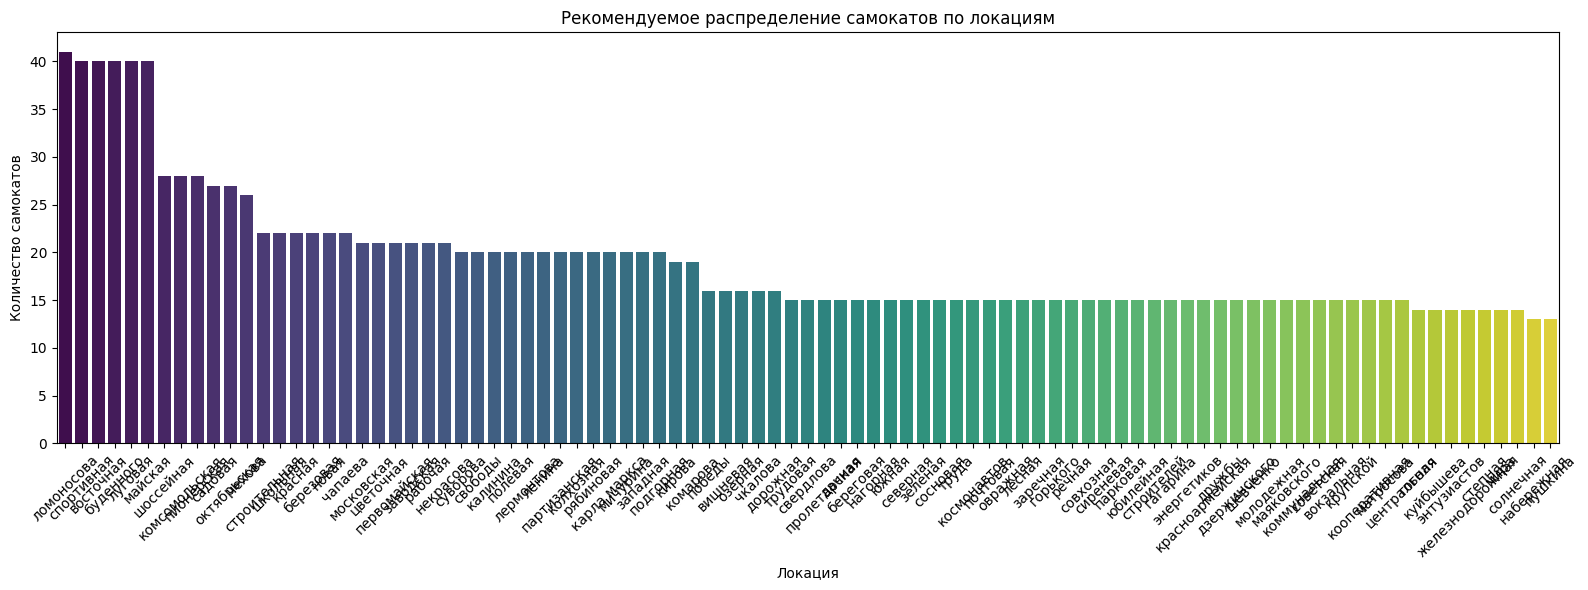

In [140]:
balance['total_traffic'] = balance['arrivals'] + balance['departures']

# Шаг 2: Посчитаем долю трафика каждой станции
balance['traffic_share'] = balance['total_traffic'] / balance['total_traffic'].sum()

# Шаг 3: Задаем общее количество самокатов (например, 1000)
total_scooters = balance[balance['net_flow'] >= 0]['net_flow'].sum()
balance['target_scooters'] = (balance['traffic_share'] * total_scooters).round().astype(int)

# Шаг 4: Подгоняем так, чтобы сумма была ровно равна total_scooters
diff = total_scooters - balance['target_scooters'].sum()
if diff != 0:
    # Добавляем или убавляем по одной штуке с самых трафиковых точек
    adjust_indices = balance['total_traffic'].sort_values(ascending=(diff < 0)).index[:abs(diff)]
    balance.loc[adjust_indices, 'target_scooters'] += np.sign(diff)

# Результат
final_distribution = balance[['Location', 'target_scooters']].sort_values(by='target_scooters', ascending=False)

# Визуализация
plt.figure(figsize=(16, 6))
sns.barplot(data=final_distribution, x='Location', y='target_scooters', palette='viridis')
plt.xticks(rotation=45)
plt.title('Рекомендуемое распределение самокатов по локациям')
plt.ylabel('Количество самокатов')
plt.xlabel('Локация')
plt.tight_layout()
plt.show()


In [141]:
final_distribution['target_scooters'].sum() == balance[balance['net_flow'] >= 0]['net_flow'].sum()

True

# 2.2. Изучить накопительное поведение разницы в трафике в каждой точке

Группировка данных по каждой точке, считаем отток и приток по каждому времени.

In [142]:
import pandas as pd

# Преобразуем данные в нужный формат
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date  # Извлекаем только дату

# Отток и приток по точкам (по каждой локации)
outflow = df.groupby(['Date', 'Start Location']).size().reset_index(name='outflow')
inflow = df.groupby(['Date', 'End Location']).size().reset_index(name='inflow')

# Переименуем для объединения данных
outflow.rename(columns={'Start Location': 'Location'}, inplace=True)
inflow.rename(columns={'End Location': 'Location'}, inplace=True)

# Объединяем отток и приток
net_flow = pd.merge(inflow, outflow, on=['Date', 'Location'], how='outer').fillna(0)

# Рассчитываем разницу в трафике
net_flow['net_change'] = net_flow['inflow'] - net_flow['outflow']

# Накопительная сумма для каждой точки по дням
net_flow.sort_values(['Location', 'Date'], inplace=True)
net_flow['cumsum'] = net_flow.groupby(['Location'])['net_change'].cumsum()

# Просмотр результатов
print(net_flow.head())


           Date   Location  inflow  outflow  net_change  cumsum
0    2023-04-22  береговая     7.0      5.0         2.0     2.0
91   2023-04-23  береговая     9.0      6.0         3.0     5.0
182  2023-04-24  береговая     7.0      5.0         2.0     7.0
273  2023-04-25  береговая     3.0      5.0        -2.0     5.0
364  2023-04-26  береговая     4.0      5.0        -1.0     4.0


**Построение графика накопительной разницы по точкам**

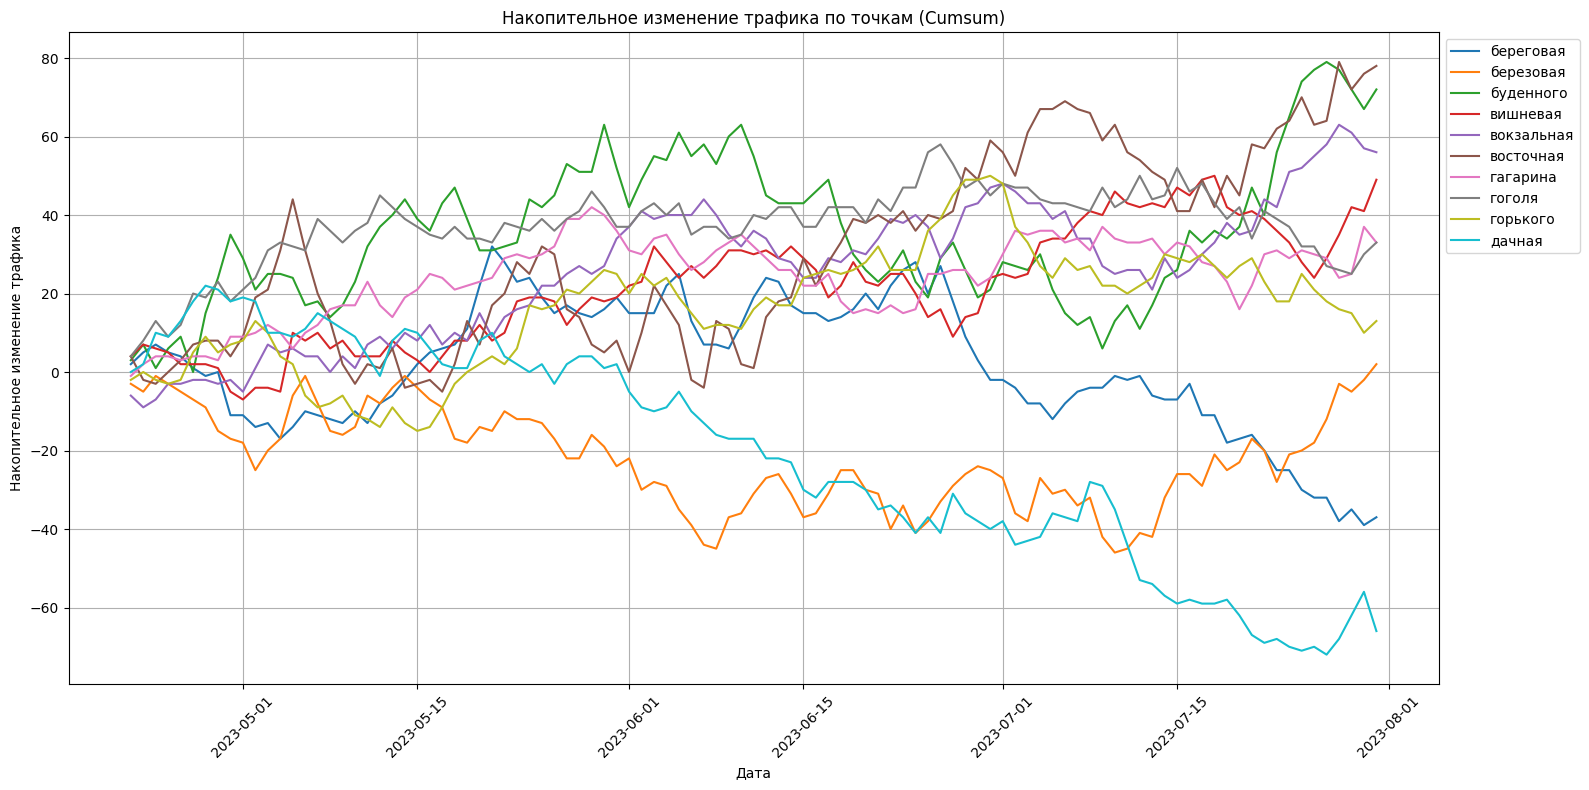

In [143]:
import matplotlib.pyplot as plt

# Группируем по точке и строим графики для каждой точки
locations = net_flow['Location'].unique()

plt.figure(figsize=(16, 8))

for i, loc in enumerate(locations[:10]):  # Ограничим вывод 10 точками для наглядности
    temp = net_flow[net_flow['Location'] == loc]
    plt.plot(temp['Date'], temp['cumsum'], label=loc)

plt.title('Накопительное изменение трафика по точкам (Cumsum)')
plt.xlabel('Дата')
plt.ylabel('Накопительное изменение трафика')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Задача 2: Определить необходимое количество самокатов в каждой точке и районе для удовлетворения спроса в полном объеме**

In [144]:
# Максимальное количество самокатов по каждой точке
required_scooters = net_flow.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)

# Просмотр результатов
print(required_scooters.head())


     Location  Required Scooters
0   береговая               32.0
1   березовая                2.0
2   буденного               79.0
3    вишневая               50.0
4  вокзальная               63.0


**Определение необходимого количества самокатов по районам**

In [145]:
# Добавляем информацию о районах
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')

# Рассчитываем необходимое количество самокатов по районам
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()

# Просмотр результатов
print(district_scooters.head())


    Start District  Required Scooters
0         заречный              168.0
1        ленинский              378.0
2      октябрьский              381.0
3  северо-западный              467.0
4      центральный              801.0


**Построение графиков для самокатов по точкам и районам.**




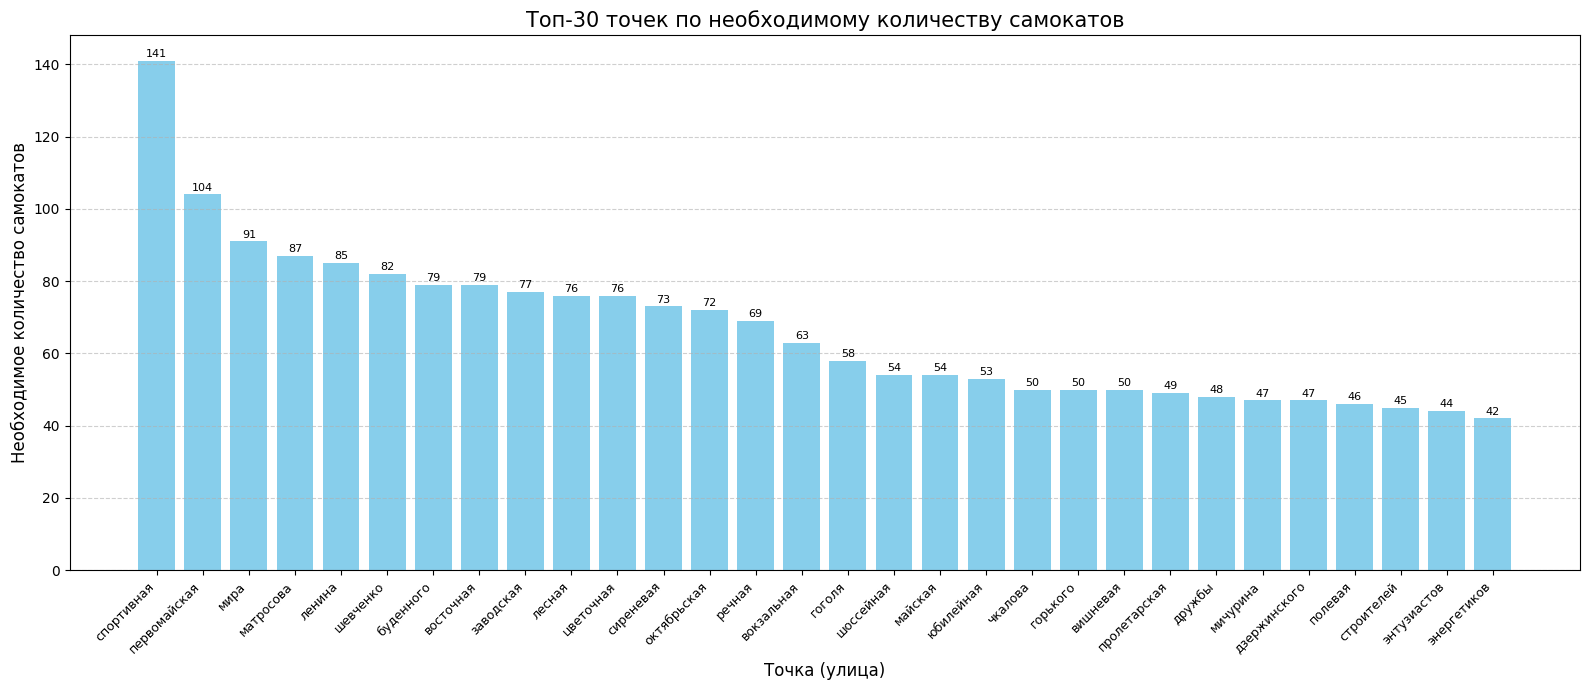

In [146]:
import matplotlib.pyplot as plt

# Отбираем топ-30 точек с наибольшим спросом
top_n = 30
top_scooters = required_scooters.sort_values('Required Scooters', ascending=False).head(top_n)

# Создаём график
plt.figure(figsize=(16, 7))
bars = plt.bar(top_scooters['Location'], top_scooters['Required Scooters'], color='skyblue')

# Добавляем подписи на столбиках
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

# Добавляем пояснение
plt.text(0, top_scooters['Required Scooters'].max() + 3,
         f'',
         fontsize=11, ha='left', va='bottom', color='green')

# Оформление графика
plt.title(f'Топ-{top_n} точек по необходимому количеству самокатов', fontsize=15)
plt.xlabel('Точка (улица)', fontsize=12)
plt.ylabel('Необходимое количество самокатов', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


**По районам -график показывает, сколько самокатов требуется для покрытия ежедневного спроса в различных районах города. Высокие столбцы на графике указывают на районы с более интенсивным спросом на самокаты. В нашем случае - центральный**

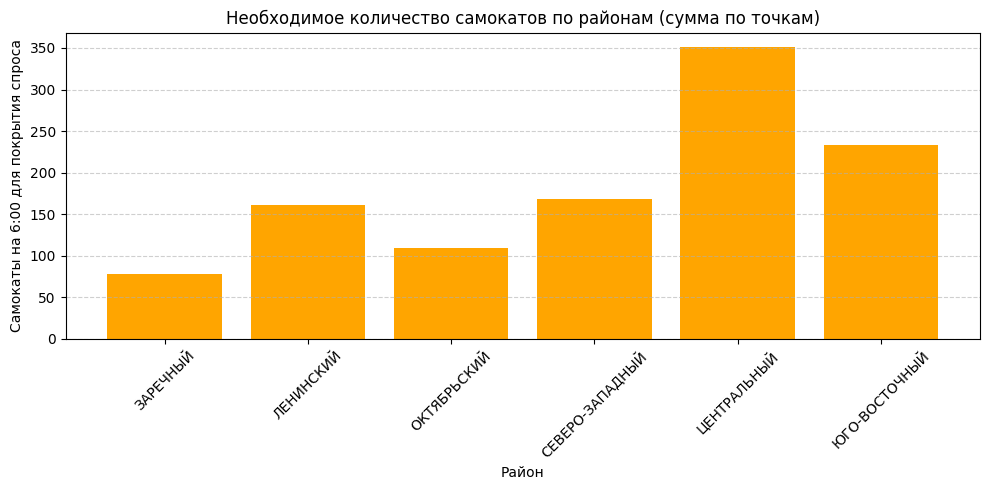

In [147]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подготовка
df['Start Date'] = pd.to_datetime(df['Start Date'])
df['End Date'] = pd.to_datetime(df['End Date'])
df['Date'] = df['Start Date'].dt.date
df['Hour'] = df['Start Date'].dt.hour

# 2. Отток и приток по точкам ПОЧАСОВО
out_hour = df.groupby(['Date', 'Hour', 'Start Location']).size().reset_index(name='outflow')
in_hour = df.groupby(['Date', 'Hour', 'End Location']).size().reset_index(name='inflow')

out_hour.rename(columns={'Start Location': 'Location'}, inplace=True)
in_hour.rename(columns={'End Location': 'Location'}, inplace=True)

# 3. Объединение
net_hour = pd.merge(in_hour, out_hour, on=['Date', 'Hour', 'Location'], how='outer').fillna(0)
net_hour['net_change'] = net_hour['inflow'] - net_hour['outflow']

# 4. Накопительный net_change в пределах каждого дня
net_hour.sort_values(['Location', 'Date', 'Hour'], inplace=True)
net_hour['cumsum'] = net_hour.groupby(['Location', 'Date'])['net_change'].cumsum()

# 5. Определяем максимум cumsum в течение каждого дня
daily_max = net_hour.groupby(['Location', 'Date'])['cumsum'].max().reset_index()

# 6. Финальное нужное количество самокатов в точке — максимум по дням
required_scooters = daily_max.groupby('Location')['cumsum'].max().reset_index()
required_scooters.rename(columns={'cumsum': 'Required Scooters'}, inplace=True)

# 7. Привязка районов
location_district_map = df[['Start Location', 'Start District']].drop_duplicates()
required_scooters = required_scooters.merge(location_district_map, left_on='Location', right_on='Start Location', how='left')

# 8. Расчёт по районам (удаляем дубли и приводим к верхнему регистру)
required_scooters['Start District'] = required_scooters['Start District'].str.upper()  # Приводим к верхнему регистру
district_scooters = required_scooters.groupby('Start District')['Required Scooters'].sum().reset_index()

# Убираем повторяющиеся районы
district_scooters = district_scooters.drop_duplicates(subset='Start District')

# -----------------------------
# 📊 ГРАФИК: По районам
# -----------------------------
plt.figure(figsize=(10, 5))
bars = plt.bar(district_scooters['Start District'], district_scooters['Required Scooters'], color='orange')

plt.title('Необходимое количество самокатов по районам (сумма по точкам)')
plt.xlabel('Район')
plt.ylabel('Самокаты на 6:00 для покрытия спроса')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 3.Исследовать корреляцию между параметрами погодных условий

# Гипотезы - 6 шт

* Нулевая - Влияет ли солнечность погоды на длину поездки?
* Альернатива - Солнечность погоды не влияет на длину поездки.

In [150]:
df[['Sunshine Duration', 'Distance']]

,Sunshine Duration,Distance
0,16.969696,4069.0
1,16.969696,4515.0
2,16.969696,4520.0
3,16.969696,3881.0
4,16.969696,4029.0
...,...,...
91952,0,3302.0
91953,0,4992.0
91954,0,2781.0
91955,0,6466.0


In [213]:
from scipy.stats import spearmanr

filtered = df[['Distance', 'Sunshine Duration']].dropna()
correlation, p_value = spearmanr(filtered['Sunshine Duration'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")


Корреляция: -0.003565046460085018
p-значение: 0.27966680533904187


Нулевая гипотиза опровергнута, значит можем утверждать, что **солнечность погоды не влияет на длину поездки**

* Нулевая - Влияет ли день недели на длину поездки?
* Альернатива - День недели не влияет на длину поездки.

In [222]:
filtered = df[['Distance', 'weekday']].dropna()
correlation, p_value = spearmanr(filtered['weekday'], filtered['Distance'])

print(f"Корреляция: {correlation}")
print(f"p-значение: {p_value}")

Корреляция: 0.05725738898655781
p-значение: 1.2326230409190073e-67


Вывод: да, **есть сильная зависимость между днем недели и длиной поездки**

Обосновать для более сильных корреляций - имеет ли это смысл

In [237]:
df['Temperature'] = df['Temperature'].astype(float)
df['Precipitation Total'] = df['Precipitation Total'].astype(float)
df['Wind Gust'] = df['Wind Gust'].astype(float)
df['Wind Speed'] = df['Wind Speed'].astype(float) 
df['Cloud Cover Total'] = df['Cloud Cover Total'].astype(float)

Calculating correlations: 100%|████████████████████████████████████████████████████████| 27/27 [03:50<00:00,  8.53s/it]


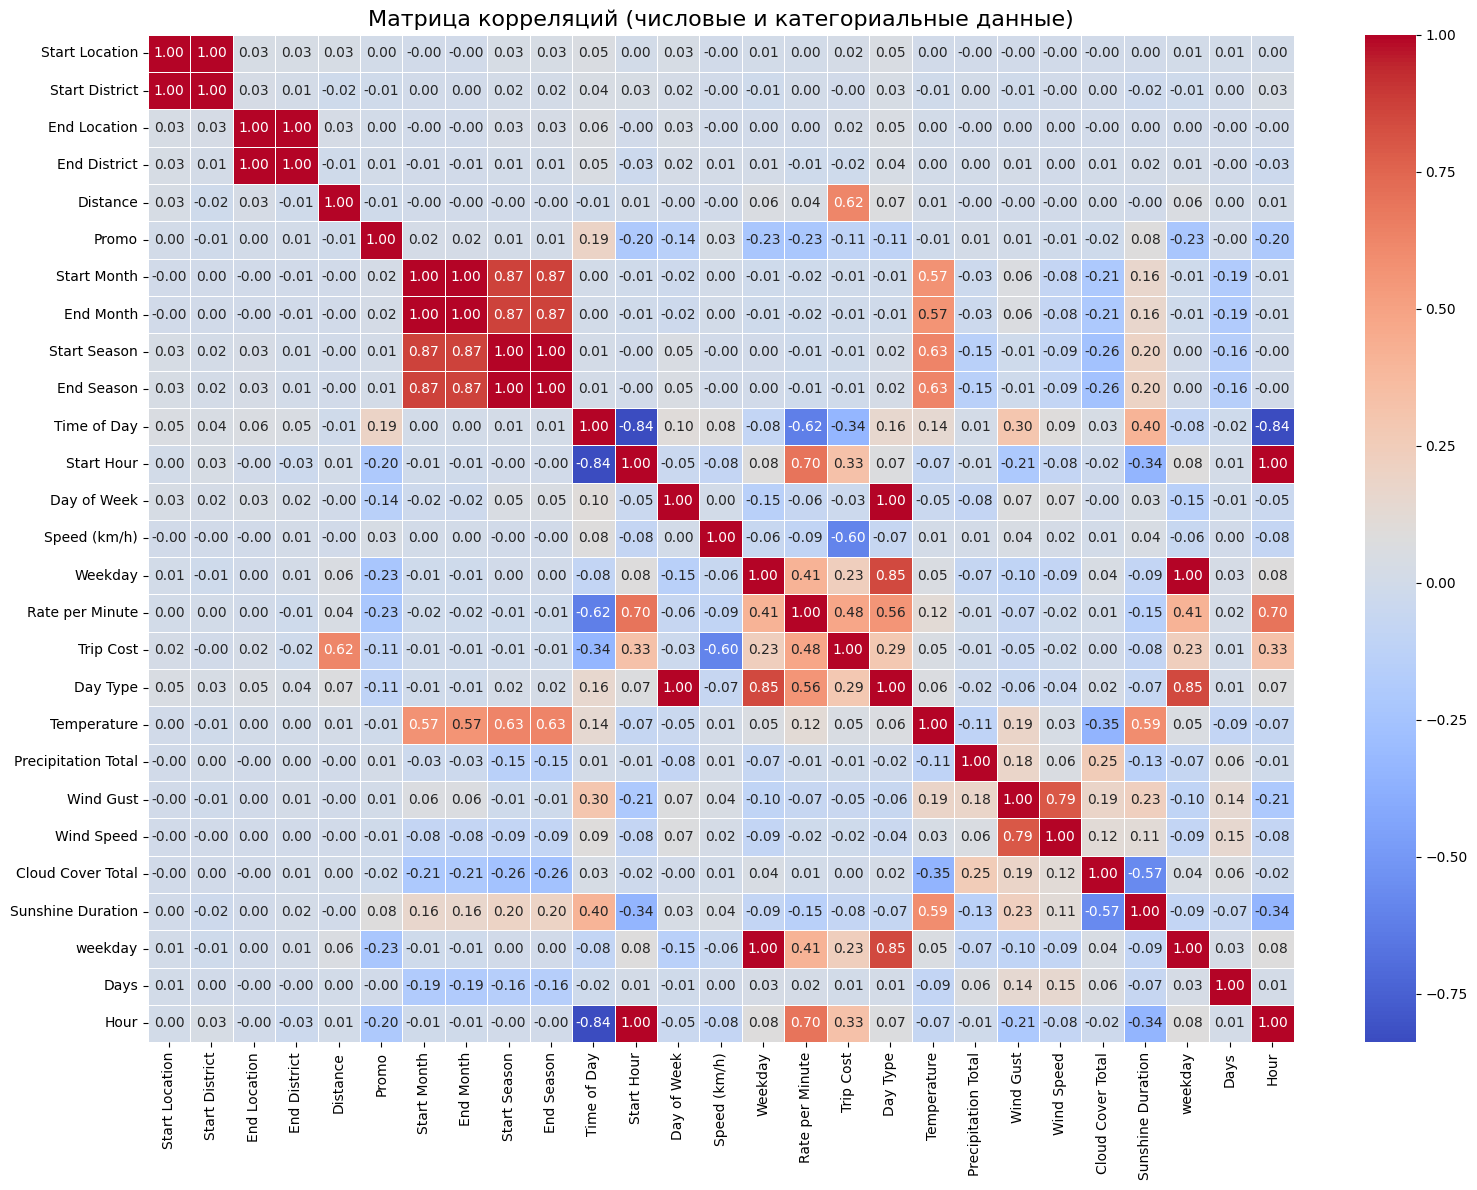

In [245]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr, spearmanr, chi2_contingency
from tqdm import tqdm

# Функция для вычисления корреляции между столбцами
def calc_correlation(col1, col2):
    if col1.dtype == 'object' and col2.dtype == 'object':
        contingency_table = pd.crosstab(col1, col2)
        chi2, _, _, _ = chi2_contingency(contingency_table)
        cramer_v = np.sqrt(chi2 / (col1.shape[0] * (min(contingency_table.shape) - 1)))
        return cramer_v
    elif np.issubdtype(col1.dtype, np.number) and np.issubdtype(col2.dtype, np.number):
        corr, _ = pearsonr(col1, col2)
        return corr
    else:
        corr, _ = spearmanr(col1, col2)
        return corr

# Удаляем неинформативные или временные столбцы
drop_cols = [
    'Start Date', 'End Date', 'Id', 'Duration', 'Datetime',
    'Time of the year', 'Time Start', 'Time End',
    'Date', 'DateOnly'
]
columns = [col for col in df.columns if col not in drop_cols]

# Создаем пустую матрицу для хранения корреляций
correlation_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

# Вычисляем корреляции только для верхней треугольной матрицы
for i, col1 in enumerate(tqdm(columns, desc="Calculating correlations")):
    for j in range(i, len(columns)):
        col2 = columns[j]
        try:
            corr = calc_correlation(df[col1], df[col2])
            correlation_matrix.loc[col1, col2] = corr
            correlation_matrix.loc[col2, col1] = corr  # симметрия
        except Exception as e:
            correlation_matrix.loc[col1, col2] = np.nan
            correlation_matrix.loc[col2, col1] = np.nan
            print(f"Ошибка при расчете корреляции между {col1} и {col2}: {e}")

# Строим тепловую карту
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляций (числовые и категориальные данные)', fontsize=16)
plt.tight_layout()
plt.show()
